In [ ]:
"""
RSA from PeriStim NPZs
--------------
Each NPZ file corresponds to a block of trials:
  - separate by targets (Left or right))
  - Baseline or a BR_File stim condition
  - data: neural rates

We convert each block into a per-trial feature matrix X:
  X shape is (n_trials, n_features)

Then, within each target (A/B), we stack blocks after flatten:
  X_target = vstack(X_block_1, X_block_2, ...)
  
Compute correlation across trials:
  corr_mat = corrcoef(X_target)   -> shape (n_trials_total, n_trials_total)

We plot corr_mat with either:
  - block boundaries + block labels (main RSA)
  - trial index ticks (control reaches only)
and we also save corr_mat to a .mat file
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import savemat

import RCP_analysis as rcp

# Paths
REPO_ROOT = Path().resolve().parents[2]
PARAMS = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
FIG_DIR = OUT_BASE / "figures" / "rsa_from_peristim"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_DIRS = [
    PERI_ROOT / "Target_A",
    PERI_ROOT / "Target_B",
]

# Plotting
def _plot_rdm_conds(
    corr_mat: np.ndarray,
    block_sizes: list[int],
    block_labels: list[str],
    title: str,
    out_svg,
    ax = None,
    vmin: float = -0.75,
    vmax: float = 0.75,
    show: bool = False,
):
    """
    Simple plot function to plot corr_mat (nTrial x nTrial)
    With ticks at block boundaries and labels at centers.
    Each block corresponds to one condition block (one NPZ file)
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 10))
    else:
        fig = ax.figure

    im = ax.imshow(
        corr_mat,
        aspect="equal",
        origin="upper",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title, fontsize=14)

    # Compute boundary locations between blocks in trial index space.
    cum = np.cumsum(block_sizes)
    starts = np.r_[0, cum[:-1]]
    boundaries = cum[:-1] - 0.5                   # boundary lines between trials / Position for ticks
    centers = starts + (np.asarray(block_sizes) / 2.0) - 0.5  # Position for labels

    # Draw ticks
    ax.set_xticks(boundaries, minor=True)
    ax.set_yticks(boundaries, minor=True)
    ax.tick_params(axis="x", which="minor", length=6, width=1.2)
    ax.tick_params(axis="y", which="minor", length=6, width=1.2)

    # Hide center ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # Add condition labels
    for c, lab in zip(centers, block_labels):
        ax.text(
            c, -0.04,
            lab,
            transform=ax.get_xaxis_transform(),
            ha="right",
            va="top",
            fontsize=11,
            rotation=45,
            clip_on=False,
        )
        ax.text(
            -0.04,
            c,
            lab,
            transform=ax.get_yaxis_transform(),
            ha="right",
            va="center",
            fontsize=11,
            clip_on=False,
        )

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Correlation (r)")

    if own_fig:
        fig.tight_layout()
        if out_svg is not None:
            fig.savefig(out_svg, dpi=300)
            print(f"[rsa] wrote {out_svg}")
        if show:
            plt.show()
        plt.close(fig)


def _plot_rdm_trial_index(
    corr_mat: np.ndarray,
    title: str,
    out_svg,
    ax=None,
    vmin: float = -0.75,
    vmax: float = 0.75,
    tick_every: int = 5,
    tick_start: int = 1,
):
    """
    Plot corr_mat with trial index ticks (for control only)
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 10))
    else:
        fig = ax.figure

    im = ax.imshow(
        corr_mat,
        aspect="equal",
        origin="upper",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title, fontsize=14)

    n = corr_mat.shape[0]
    if n == 0:
        ax.set_xticks([]); ax.set_yticks([])
    else:
        # Set ticks location at trials
        step = max(1, int(tick_every))
        ticks = np.arange(0, n, step, dtype=int)
        labels = [str(i + tick_start) for i in ticks]
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels(labels, rotation=45, fontsize=7)
        ax.set_yticklabels(labels, fontsize=7)
        ax.set_xlabel("Trial index")
        ax.set_ylabel("Trial index")

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Correlation (r)")
    cb.set_ticks([vmin, 0.0, vmax])

    if own_fig:
        fig.tight_layout()
        if out_svg is not None:
            fig.savefig(out_svg, dpi=300, bbox_inches="tight")
            print(f"[rsa] wrote {out_svg}")
        plt.show()
        plt.close(fig)


# Helpers for extracting info from npz files
def get_baseline_port(fname: str):
    """
    Extract baseline port from file such as,
      baseline__NRR_RW011_Depth_43.0_port_B_target_A.npz

    Returns:
    Port A or B ("A" / "B" or None)
    """
    parts = fname.split("_")
    for i, p in enumerate(parts):
        if p == "port" and i + 1 < len(parts):
            return parts[i + 1]
    return None

def _get_data_from_peristim_npz(
    npz_path: Path,
    source: str,
    corr_win_ms,
    channels=None,
    time_as_features: bool = False,
    min_valid_features: int = 2,
):
    """
    Get feature matrix (X) from npz file (one block of trials) for one condition

    Outputs:
    X : (nTrials_kept, nFeatures)
      Each row is one trial
    labels : list[str]
      Trial labels for debugging; aligned with X rows
    info : dict
      Metadata including condition, target, is_baseline

    Npz contains:
      - NPRW_rates_zeroed or UA_rates_zeroed : (nTrials, nChannels, T)
      - NPRW_rel_t or UA_rel_t (T, )

    If time_as_features=False (default): # TODO fix this
      features = mean rate in [w0,w1] per channel => (n_trials, n_channels)

    If time_as_features=True:
      features = flatten (channels x timebins_in_window) => (n_trials, n_channels*T_sel)
    """
    peristim_npz = np.load(npz_path, allow_pickle=True)

    # Choose time axis and and data
    if source == "NPRW":
        t_key = "NPRW_rel_t"
        rate_key = "NPRW_rates_zeroed"
    elif source == "UA":
        t_key = "UA_rel_t"
        rate_key = "UA_rates_zeroed"
    else:
        raise ValueError(f"source must be 'NPRW' or 'UA', got {source!r}")

    if t_key not in peristim_npz.files:
        return np.zeros((0, 0), float), [], {"cond": None, "n_trials": 0, "n_ch": 0}

    rel_t = peristim_npz[t_key].astype(float)  # (T,)

    # ---- block-level metadata (condition & target) ----
    br_idx = None
    if "br_idx" in peristim_npz.files:
        try:
            br_idx = int(peristim_npz["br_idx"])
        except Exception:
            br_idx = None

    target = npz_path.parent.name                     # "Target_A" / "Target_B"
    is_baseline = npz_path.name.startswith("baseline__")
    cond_label = "Baseline" if is_baseline else br_idx

    # Get time window within rel_t
    w0, w1 = map(float, corr_win_ms)
    mask_t = (rel_t >= w0) & (rel_t <= w1)
    if not np.any(mask_t):
        print(f"[rsa][warn] window {corr_win_ms} ms has no samples; skipping {npz_path.name}")
        return np.zeros((0, 0), float), [], {"cond": cond_label, "n_trials": 0, "n_ch": 0}

    if rate_key not in peristim_npz.files:
        return np.zeros((0, 0), float), [], {"cond": cond_label, "n_trials": 0, "n_ch": 0}

    rates = peristim_npz[rate_key].astype(float)  # (n_trials, n_ch, T)

    # sanity checks
    if rates.size == 0 or rates.ndim != 3 or rates.shape[-1] != rel_t.size:
        return np.zeros((0, 0), float), [], {
            "cond": cond_label,
            "n_trials": 0,
            "n_ch": rates.shape[1] if rates.ndim >= 2 else 0,
        }

    n_trials, n_ch, _ = rates.shape

    # Channel subset
    if channels is not None:
        if isinstance(channels, slice):
            ch_idx = np.arange(n_ch)[channels]
        else:
            ch_idx = np.asarray(channels)
            if ch_idx.dtype == bool:
                if ch_idx.size != n_ch:
                    raise ValueError(f"channels bool mask len={ch_idx.size} != n_ch={n_ch}")
                ch_idx = np.flatnonzero(ch_idx)
        rates = rates[:, ch_idx, :]
        n_trials, n_ch, _ = rates.shape

    # Build trial feature matrix
    if time_as_features: # TODO Clean this up for per channel RSA data
        # Keep the *time bins* as features: (trial, ch, T_sel) -> (trial, ch*T_sel)
        X = rates[:, :, mask_t].reshape(n_trials, -1)
    else:
        # Collapse time: mean within window per channel -> (trial, ch)
        X = np.nanmean(rates[:, :, mask_t], axis=2)

    # Drop trials that has too little features after flatten
    valid_trials = np.isfinite(X).sum(axis=1) >= int(min_valid_features)
    keep_idx = np.flatnonzero(valid_trials)
    if keep_idx.size == 0:
        return np.zeros((0, 0), float), [], {"cond": cond_label, "n_trials": 0, "n_ch": X.shape[1]}

    X = X[keep_idx, :]

    # Trial labels
    n_final = X.shape[0]
    labels = [
        f"{'Baseline' if is_baseline else f'cond{br_idx}'}_{target}_t{j+1}"
        for j in range(n_final)
    ]

    info = {
        "cond": cond_label, # "Baseline" or int br_idx
        "target": target,
        "is_baseline": bool(is_baseline),
        "n_trials": int(n_final),
        "n_ch": int(X.shape[1]),
        "file": npz_path.name,
    }
    return X, labels, info


# Save mat
def _save_rsa_mat(
    out_mat: Path,
    corr_mat: np.ndarray,
    target: str,
    source: str,
    corr_win_ms: tuple[float, float],
    block_sizes: list[int],
    block_labels: list[str],
    X_shape=None,
):
    """
    Save RSA matrix to a .mat file

    Saves:
      corr_mat - (nTrials, nTrials)
      meta - dictionary with target / source (UA or NPRW) / window and condition labels
    """
    out_mat = Path(out_mat)
    out_mat.parent.mkdir(parents=True, exist_ok=True)

    md = {
        "target": target,
        "source": source,
        "corr_win_ms": np.asarray(corr_win_ms, float),
        "n_trials": int(corr_mat.shape[0]),
        "cond_sizes": np.asarray(block_sizes, int),
        "cond_labels": np.asarray(block_labels, dtype=object),
        "X_shape": np.asarray(X_shape if X_shape is not None else (-1, -1), int),
    }

    savemat(
        out_mat,
        {"corr_mat": np.asarray(corr_mat, float), "meta": md},
        do_compression=True,
        long_field_names=True,
    )
    print(f"[rsa] wrote mat {out_mat}")


# RSA Main function
def run_trial_rsa_from_peristim(
    source,
    corr_win_ms,
    *,
    cond_label_extras=None,
    vmin: float = -0.75,
    vmax: float = 0.75,
    z_score_features: bool = True,
    save_svg: bool = True,
    min_trials_per_cond: int = 4,
    min_valid_features: int = 2,
    file_slice=slice(None),
    skip_conds=None,
    keep_baseline_port="A",
    channels=None,
    cond_order=None,
    extra_block_npz=None,
    extra_block_label: str = "Rest",
    show: bool = False,
    out_subdir=None,
    time_as_features: bool = False,
):

    """
    Compute and plot RSA per target

    cond_order sets the order in which the blocks are sorted
      Blocks sorted by (target, cond_rank, filename)
    If nothing is passed then (target, filename)
    """
    assert source not in (None, ""), "run_trial_rsa_from_peristim: 'source' is required (e.g., 'NPRW' or 'UA')."
    assert corr_win_ms is not None, "run_trial_rsa_from_peristim: 'corr_win_ms' is required, e.g. (125.0, 225.0)."
    assert isinstance(corr_win_ms, (tuple, list)) and len(corr_win_ms) == 2, \
        "run_trial_rsa_from_peristim: corr_win_ms must be a 2-tuple like (w0_ms, w1_ms)."
    assert float(corr_win_ms[0]) < float(corr_win_ms[1]), \
        "run_trial_rsa_from_peristim: corr_win_ms must satisfy w0 < w1."

    cond_label_extras = cond_label_extras or {}
    skip_conds = set(skip_conds or [])

    print(f"[rsa] running RSA for {source!r}, window={corr_win_ms[0]}–{corr_win_ms[1]} ms")

    # Collect NPZ for both targets
    npz_files = []
    for td in TARGET_DIRS:
        if td.exists():
            npz_files.extend(sorted(td.glob("*.npz")))
    npz_files = npz_files[file_slice]
    if not npz_files:
        raise SystemExit(f"[rsa] no PeriStim NPZs found in {TARGET_DIRS}")

    # Read NPZ
    blocks = []
    skipped = { # Collect conditions that are skipped for debugging
        "baseline_wrong_port": [],
        "in_skip_conds": set(),
        "too_few_trials": set(),
        "missing_or_empty": [],
    }

    for path in npz_files:
        X_cond, labels, info = _get_data_from_peristim_npz(
            path,
            source=source,
            corr_win_ms=corr_win_ms,
            channels=channels,
            time_as_features=time_as_features,
            min_valid_features=min_valid_features,
        )

        cond = info.get("cond", None) # "Baseline" or int br_idx
        is_baseline = bool(info.get("is_baseline", False))
        target = info.get("target", path.parent.name)
        n_trials = int(info.get("n_trials", 0))

        # Skip empty blocks
        if X_cond.size == 0 or n_trials == 0:
            skipped["missing_or_empty"].append(path.name)
            continue

        # Only collect baseline for selected port
        if is_baseline and keep_baseline_port is not None:
            port = get_baseline_port(path.name)
            if port != keep_baseline_port:
                skipped["baseline_wrong_port"].append(path.name)
                continue

        cond_norm = "Baseline" if is_baseline else cond

        # Skip certain npzs if stated in cond_norm
        if (not is_baseline) and (cond_norm is not None) and (cond_norm in skip_conds):
            skipped["in_skip_conds"].add(int(cond_norm))
            continue

        if (not is_baseline) and (n_trials < min_trials_per_cond):
            if cond_norm is not None:
                skipped["too_few_trials"].add(int(cond_norm))
            else:
                skipped["missing_or_empty"].append(path.name)
            continue

        blocks.append(
            dict(
                X=X_cond,
                labels=labels,
                n_trials=n_trials,
                target=target,
                cond=cond_norm,
                path=path,
                is_baseline=is_baseline,
            )
        )

    # Print skips for debugging
    parts = []
    if skipped["in_skip_conds"]:
        parts.append("skip_conds=" + ",".join(map(str, sorted(skipped["in_skip_conds"]))))
    if skipped["too_few_trials"]:
        parts.append(f"too_few_trials(<{min_trials_per_cond})=" + ",".join(map(str, sorted(skipped["too_few_trials"]))))
    if skipped["baseline_wrong_port"]:
        parts.append(f"baseline_wrong_port(!={keep_baseline_port})={len(skipped['baseline_wrong_port'])}")
    if skipped["missing_or_empty"]:
        parts.append("empty_or_missing=" + str(len(skipped["missing_or_empty"])))
    if parts:
        print("[rsa][skip-summary] " + " | ".join(parts))

    if not blocks:
        raise SystemExit("[rsa] no conditions with enough trials")

    # Add extra block as stated. This is for at REST condition append to each target later #TODO fix this if the target for at rest is fixed
    X_extra = None
    if extra_block_npz is not None:
        extra_block_npz = Path(extra_block_npz).expanduser()
        X_extra, _, info_extra = _get_data_from_peristim_npz(
            extra_block_npz,
            source=source,
            corr_win_ms=corr_win_ms,
            channels=channels,
            time_as_features=time_as_features,
            min_valid_features=min_valid_features,
        )
        if X_extra.size == 0 or X_extra.shape[0] == 0:
            print(f"[rsa][warn] extra block empty or missing: {extra_block_npz}")
            X_extra = None
        else:
            print(f"[rsa] extra block loaded: {extra_block_npz.name}  n_trials={X_extra.shape[0]}")

    # Ordering of conditions as provided
    if cond_order is not None:
        cond_order = list(cond_order)
        order_map = {c: i for i, c in enumerate(cond_order)}

        def cond_rank(c):
            # baseline comes first unless caller explicitly places it elsewhere
            if c == "Baseline":
                return order_map.get("Baseline", -1)
            return order_map.get(c, 10**9)

        blocks.sort(key=lambda b: (b["target"], cond_rank(b["cond"]), str(b["path"])))
    else:
        # stable-ish default: target then filename
        blocks.sort(key=lambda b: (b["target"], str(b["path"])))

    # ---- determine targets present ----
    targets_present = [t for t in ("Target_A", "Target_B") if any(b["target"] == t for b in blocks)]
    if not targets_present:
        targets_present = sorted(set(b["target"] for b in blocks))

    fig, axes = plt.subplots(1, len(targets_present), figsize=(8 * len(targets_present), 8), squeeze=False)
    axes = axes[0]

    for ax, target in zip(axes, targets_present):
        blocks_t = [b for b in blocks if b["target"] == target]
        if not blocks_t:
            ax.set_visible(False)
            continue

        # Stack blocks within target panel
        X_blocks_t = [b["X"] for b in blocks_t]
        sizes_t = [b["n_trials"] for b in blocks_t]
        conds_t = [b["cond"] for b in blocks_t]

        # If extra block is provided, append it to *each* target panel
        if X_extra is not None:
            feat_dims = [X.shape[1] for X in X_blocks_t] + [X_extra.shape[1]]
            if len(set(feat_dims)) > 1:
                # crop to common minimum feature dim (safer than failing)
                min_dim = min(feat_dims)
                X_blocks_t = [X[:, :min_dim] for X in X_blocks_t]
                X_extra_use = X_extra[:, :min_dim]
            else:
                X_extra_use = X_extra

            X_blocks_t = X_blocks_t + [X_extra_use]
            sizes_t = sizes_t + [X_extra_use.shape[0]]
            conds_t = conds_t + [extra_block_label]

        X_t = np.vstack(X_blocks_t)

        # z-score within target panel (feature-wise)
        if z_score_features and X_t.size:
            with np.errstate(invalid="ignore", divide="ignore"):
                mu = np.nanmean(X_t, axis=0, keepdims=True)
                sd = np.nanstd(X_t, axis=0, keepdims=True)
                X_t = (X_t - mu) / np.where(sd > 0, sd, 1.0)

        # Drop any rows containing NaN/Inf, and update block sizes accordingly
        valid_rows = np.isfinite(X_t).all(axis=1)
        if not valid_rows.all():
            X_t = X_t[valid_rows, :]

            # recompute block sizes so boundaries stay correct
            new_sizes = []
            cursor = 0
            keep_idx = np.where(valid_rows)[0]
            for sz in sizes_t:
                idx = np.arange(cursor, cursor + sz)
                new_sizes.append(int(np.intersect1d(idx, keep_idx).size))
                cursor += sz

            # drop blocks that became empty
            sizes_cond_pairs = [(s, c) for s, c in zip(new_sizes, conds_t) if s > 0]
            if not sizes_cond_pairs:
                ax.set_visible(False)
                continue
            sizes_t, conds_t = map(list, zip(*sizes_cond_pairs))

        # Similarity: correlation across trials
        corr_mat_trials = np.corrcoef(X_t)

        # Block labels for plotting
        block_labels_t = []
        for cond in conds_t:
            if isinstance(cond, str):
                base = cond_label_extras.get(cond, cond)
            else:
                base = cond_label_extras.get(cond, f"Cond {cond}")
            block_labels_t.append(base)

        target_disp = {"Target_A": "Left reaches", "Target_B": "Right reaches"}.get(target, target.replace("_", " "))
        title = f"{target_disp} ({source}) ({int(corr_win_ms[0])} to {int(corr_win_ms[1])} ms)"

        # Save per-target MAT + SVG to a dedicated directory (your current behavior)
        out_dir = PERI_ROOT / "RSA_MAT_M1i"
        out_dir.mkdir(parents=True, exist_ok=True)

        out_mat_t = out_dir / f"RSA_mat_{source}_{target}_{int(corr_win_ms[0])}-{int(corr_win_ms[1])}.mat"
        _save_rsa_mat(
            out_mat=out_mat_t,
            corr_mat=corr_mat_trials,
            target=target,
            source=source,
            corr_win_ms=corr_win_ms,
            block_sizes=sizes_t,
            block_labels=block_labels_t,
            X_shape=X_t.shape if isinstance(X_t, np.ndarray) else None,
        )

        out_svg_t = (
            out_dir / f"RSA_from_peristim_{source}_{target}_win{int(corr_win_ms[0])}-{int(corr_win_ms[1])}.svg"
            if save_svg else None
        )

        _plot_rdm_conds(
            corr_mat_trials,
            sizes_t,
            block_labels_t,
            title,
            out_svg=out_svg_t,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            show=show,
        )

    fig.tight_layout()

    # Save combined (Target A + Target B) figure
    if save_svg:
        out_dir = FIG_DIR if out_subdir is None else (FIG_DIR / out_subdir)
        out_dir.mkdir(parents=True, exist_ok=True)
        out_svg_all = out_dir / f"RSA_from_peristim_{source}_Targets_AB_win{int(corr_win_ms[0])}-{int(corr_win_ms[1])}.svg"
        fig.savefig(out_svg_all, dpi=300)
        print(f"[rsa] wrote combined figure {out_svg_all}")

    if show:
        plt.show()
    plt.close(fig)

    # quick summary
    total_trials = sum(b["n_trials"] for b in blocks)
    feat_dim = blocks[0]["X"].shape[1]
    print(f"[rsa] final: total trials (pre-extra)={total_trials}  features={feat_dim}")


# Control reaches only RSA
def run_trial_rsa_control_only_from_peristim(
    source,
    corr_win_ms,
    *,
    cond_label_extras=None,
    vmin: float = -1.0,
    vmax: float = 1.0,
    z_score_features: bool = True,
    save_svg: bool = True,
    min_trials_per_cond: int = 4,
    min_valid_features: int = 2,
    file_slice=slice(None),
    keep_baseline_port="A",
    channels=None,
    control_conds=("Baseline",),
    tick_every: int = 5,
    tick_start: int = 1,
    out_subdir: str = "control_only",
    show: bool = True,
):

    """
    Control-only RSA:
      - filter to blocks whose condition is in control_conds (default: just Baseline)
      - stack within each target
      - z-score within target (if enabled)
      - drop invalid rows
      - corrcoef(X)
      - plot with trial index ticks
    """
    cond_label_extras = cond_label_extras or {}
    control_conds = set(control_conds or [])

    # normalize baseline spelling
    control_conds_norm = set("Baseline" if (isinstance(c, str) and c.lower() == "baseline") else c for c in control_conds)

    print(f"[rsa][control] running {source!r}, window={corr_win_ms[0]}–{corr_win_ms[1]} ms")
    print(f"[rsa][control] keeping conds = {sorted(control_conds_norm, key=str)}")

    # Collect NPZs
    npz_files = []
    for td in TARGET_DIRS:
        if td.exists():
            npz_files.extend(sorted(td.glob("*.npz")))
    npz_files = npz_files[file_slice]
    if not npz_files:
        raise SystemExit(f"[rsa] no PeriStim NPZs found in {TARGET_DIRS}")

    blocks = []
    skipped = {"wrong_port": 0, "not_control": 0, "too_few_trials": 0, "empty": 0}

    for path in npz_files:
        X, labels, info = _get_data_from_peristim_npz(
            path,
            source=source,
            corr_win_ms=corr_win_ms,
            channels=channels,
            min_valid_features=min_valid_features,
        )

        cond = info.get("cond", None)
        is_baseline = bool(info.get("is_baseline", False))
        target = info.get("target", path.parent.name)
        n_trials = int(info.get("n_trials", 0))

        if X.size == 0 or n_trials == 0:
            skipped["empty"] += 1
            continue

        if is_baseline and keep_baseline_port is not None:
            port = get_baseline_port(path.name)
            if port != keep_baseline_port:
                skipped["wrong_port"] += 1
                continue

        cond_norm = "Baseline" if is_baseline else cond

        if cond_norm not in control_conds_norm:
            skipped["not_control"] += 1
            continue

        if (not is_baseline) and (n_trials < min_trials_per_cond):
            skipped["too_few_trials"] += 1
            continue

        blocks.append(dict(X=X, target=target, cond=cond_norm, path=path, n_trials=n_trials))

    print(
        f"[rsa][control][skip] wrong_port={skipped['wrong_port']} | "
        f"not_control={skipped['not_control']} | "
        f"too_few_trials={skipped['too_few_trials']} | empty={skipped['empty']}"
    )

    if not blocks:
        raise SystemExit("[rsa][control] no control blocks found after filtering")

    blocks.sort(key=lambda b: (b["target"], str(b["path"])))

    targets_present = [t for t in ("Target_A", "Target_B") if any(b["target"] == t for b in blocks)]
    if not targets_present:
        targets_present = sorted(set(b["target"] for b in blocks))

    fig, axes = plt.subplots(1, len(targets_present), figsize=(8 * len(targets_present), 8), squeeze=False)
    axes = axes[0]

    out_dir = FIG_DIR / out_subdir
    out_dir.mkdir(parents=True, exist_ok=True)

    for ax, target in zip(axes, targets_present):
        blocks_t = [b for b in blocks if b["target"] == target]
        if not blocks_t:
            ax.set_visible(False)
            continue

        # Ensure consistent feature dim within target (crop if needed)
        feat_dims = [b["X"].shape[1] for b in blocks_t]
        if len(set(feat_dims)) > 1:
            min_dim = min(feat_dims)
            print(f"[rsa][control][warn] {target}: feature dims {feat_dims} -> cropping to {min_dim}")
            X_t = np.vstack([b["X"][:, :min_dim] for b in blocks_t])
        else:
            X_t = np.vstack([b["X"] for b in blocks_t])

        if z_score_features and X_t.size:
            with np.errstate(invalid="ignore", divide="ignore"):
                mu = np.nanmean(X_t, axis=0, keepdims=True)
                sd = np.nanstd(X_t, axis=0, keepdims=True)
                X_t = (X_t - mu) / np.where(sd > 0, sd, 1.0)

        valid_rows = np.isfinite(X_t).all(axis=1)
        if not valid_rows.all():
            X_t = X_t[valid_rows, :]

        corr_mat_trials = np.corrcoef(X_t) if X_t.shape[0] > 0 else np.zeros((0, 0), float)

        target_disp = {"Target_A": "Left reaches", "Target_B": "Right reaches"}.get(target, target.replace("_", " "))
        title = f"{target_disp} ({source})  {int(corr_win_ms[0])} to {int(corr_win_ms[1])} ms"

        out_svg_t = out_dir / (
            f"RSA_control_only_{source}_{target}_win{int(corr_win_ms[0])}-{int(corr_win_ms[1])}.svg"
            if save_svg else None
        )

        _plot_rdm_trial_index(
            corr_mat_trials,
            title=title,
            out_svg=out_svg_t,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            tick_every=tick_every,
            tick_start=tick_start,
        )

    fig.tight_layout()

    if save_svg:
        out_svg_all = out_dir / f"RSA_control_only_{source}_Targets_AB_win{int(corr_win_ms[0])}-{int(corr_win_ms[1])}.svg"
        fig.savefig(out_svg_all, dpi=300)
        print(f"[rsa] wrote combined figure {out_svg_all}")

    if show:
        plt.show()
    plt.close(fig)

    print("[rsa][control] done.")


In [7]:
cond_label_extras = {
    "Baseline": "Control reaches",
    5: "400Hz (1-32)",
    6: "400Hz (1-32)",
    7: "400Hz (33-64)",
    9: "32 ch (Rest, 33-64)",
    10: "130Hz (1-32)",
    11: "130Hz (33-64)",
    12: "1-8",
    13: "5-12",
    14: "9-16",
    15: "13-20",
    16: "17-24",
    17: "21-28",
    18: "25-32",
    19: "29-36",
    20: "33-40",
    21: "37-44",
    23: "400Hz (1-32) Late",
    24: "400Hz (32-64) Late",
    25: "130Hz (1-32) Late",
    27: "130Hz (1-32) Late",
}

/tmp/ipykernel_257522/2766250887.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_local = cm.get_cmap("jet").copy()


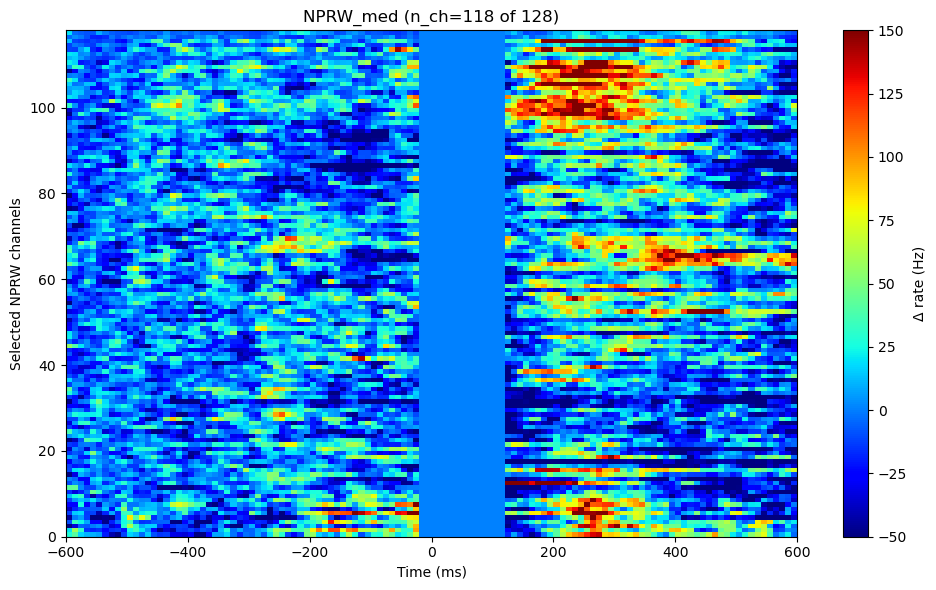

Selected channel indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117]


In [8]:
from matplotlib import cm
VMIN_NPRW, VMAX_NPRW = -50, 150

npz_path = '/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_145830__BR_015_target_A.npz'
peristim_npz = np.load(npz_path, allow_pickle=True)

NPRW_med       = peristim_npz["NPRW_med"]
NPRW_rel_t     = peristim_npz["NPRW_rel_t"]
NPRW_edges_ms  = peristim_npz["NPRW_edges_ms"]
NPRW_rates_zeroed = peristim_npz.get("NPRW_rates_zeroed", None)

# --------- QUICK CHANNEL SELECT ----------
channels = slice(0, 118)          # None = all; e.g. slice(0, 64) or [0,1,2] or bool mask len=n_ch
# ---------------------------------------

n_ch = NPRW_med.shape[0]
if channels is None:
    ch_idx = np.arange(n_ch)
elif isinstance(channels, slice):
    ch_idx = np.arange(n_ch)[channels]
else:
    ch = np.asarray(channels)
    if ch.dtype == bool:
        if ch.size != n_ch:
            raise ValueError(f"channels bool mask len={ch.size} != n_ch={n_ch}")
        ch_idx = np.flatnonzero(ch)
    else:
        ch_idx = ch.astype(int)

cmap_local = cm.get_cmap("jet").copy()
cmap_local.set_bad(color="gray")

NPRW_plot = NPRW_med[ch_idx, :]  # <-- apply selection here

# insert gap column at 58
NPRW_plot = np.concatenate(
    [NPRW_plot[:, :58], np.zeros((NPRW_plot.shape[0], 1)), NPRW_plot[:, 58:]],
    axis=1
)

y_edges = np.arange(NPRW_plot.shape[0] + 1)

plt.figure(figsize=(10, 6))
im = plt.pcolormesh(
    NPRW_edges_ms,
    y_edges,
    NPRW_plot,
    cmap=cmap_local,
    vmin=VMIN_NPRW,
    vmax=VMAX_NPRW,
    shading="auto",
    antialiased=False,
    rasterized=True,
)
plt.xlabel("Time (ms)")
plt.ylabel("Selected NPRW channels")
plt.title(f"NPRW_med (n_ch={len(ch_idx)} of {n_ch})")
plt.colorbar(im, label="Δ rate (Hz)")
plt.tight_layout()
plt.show()

print("Selected channel indices:", ch_idx)


/tmp/ipykernel_15128/3654985651.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_local_ua = cm.get_cmap('jet').copy()


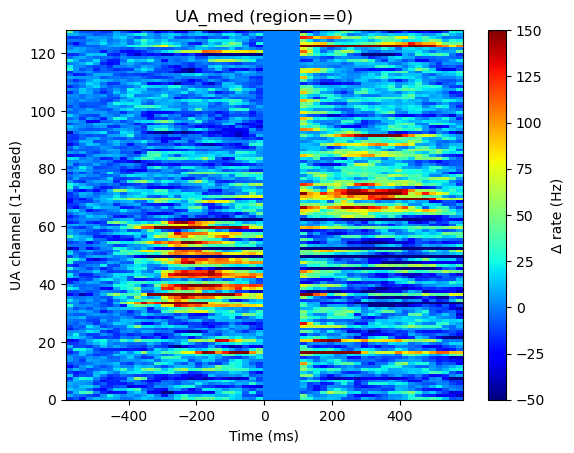

In [78]:
VMIN_UA,   VMAX_UA   = -50, 150

UA_med = peristim_npz['UA_med']
UA_rates_zeroed = peristim_npz['UA_rates_zeroed']
UA_rel_t = peristim_npz['UA_rel_t']
UA_edges_ms = peristim_npz['UA_edges_ms']
ua_ids_1based = peristim_npz['ua_ids_1based']
ua_region = peristim_npz['ua_region']
ua_region_names = peristim_npz['ua_region_names']
ua_port = peristim_npz['ua_port']
ua_nsp = peristim_npz['ua_nsp']
ua_idx_rows = peristim_npz['ua_idx_rows']

# Select for channels:
# region_loc = np.where(ua_region == 1)[0]
# y_edges = np.arange(len(region_loc) + 1)
cmap_local_ua = cm.get_cmap('jet').copy()
cmap_local_ua.set_bad(color="gray")
UA_plot = UA_med#[region_loc, :]
UA_plot = np.concatenate([UA_plot[:, :29], np.zeros((UA_plot.shape[0], 1)), UA_plot[:, 29:]],axis=1)
y_edges = np.arange(UA_plot.shape[0] + 1)

im0 = plt.pcolormesh(
    UA_edges_ms,          # x edges
    y_edges,               # y edges
    UA_plot,           # C: (n_ch, T+1)
    cmap=cmap_local_ua,
    vmin=VMIN_UA,
    vmax=VMAX_UA,
    shading="auto",
    antialiased=False,
    rasterized=True,
)
plt.xlabel("Time (ms)")
plt.ylabel("UA channel (1-based)")
plt.title(f"UA_med (region==0)")
plt.colorbar(label="Δ rate (Hz)")
# ua_ids_1based, ua_region, 


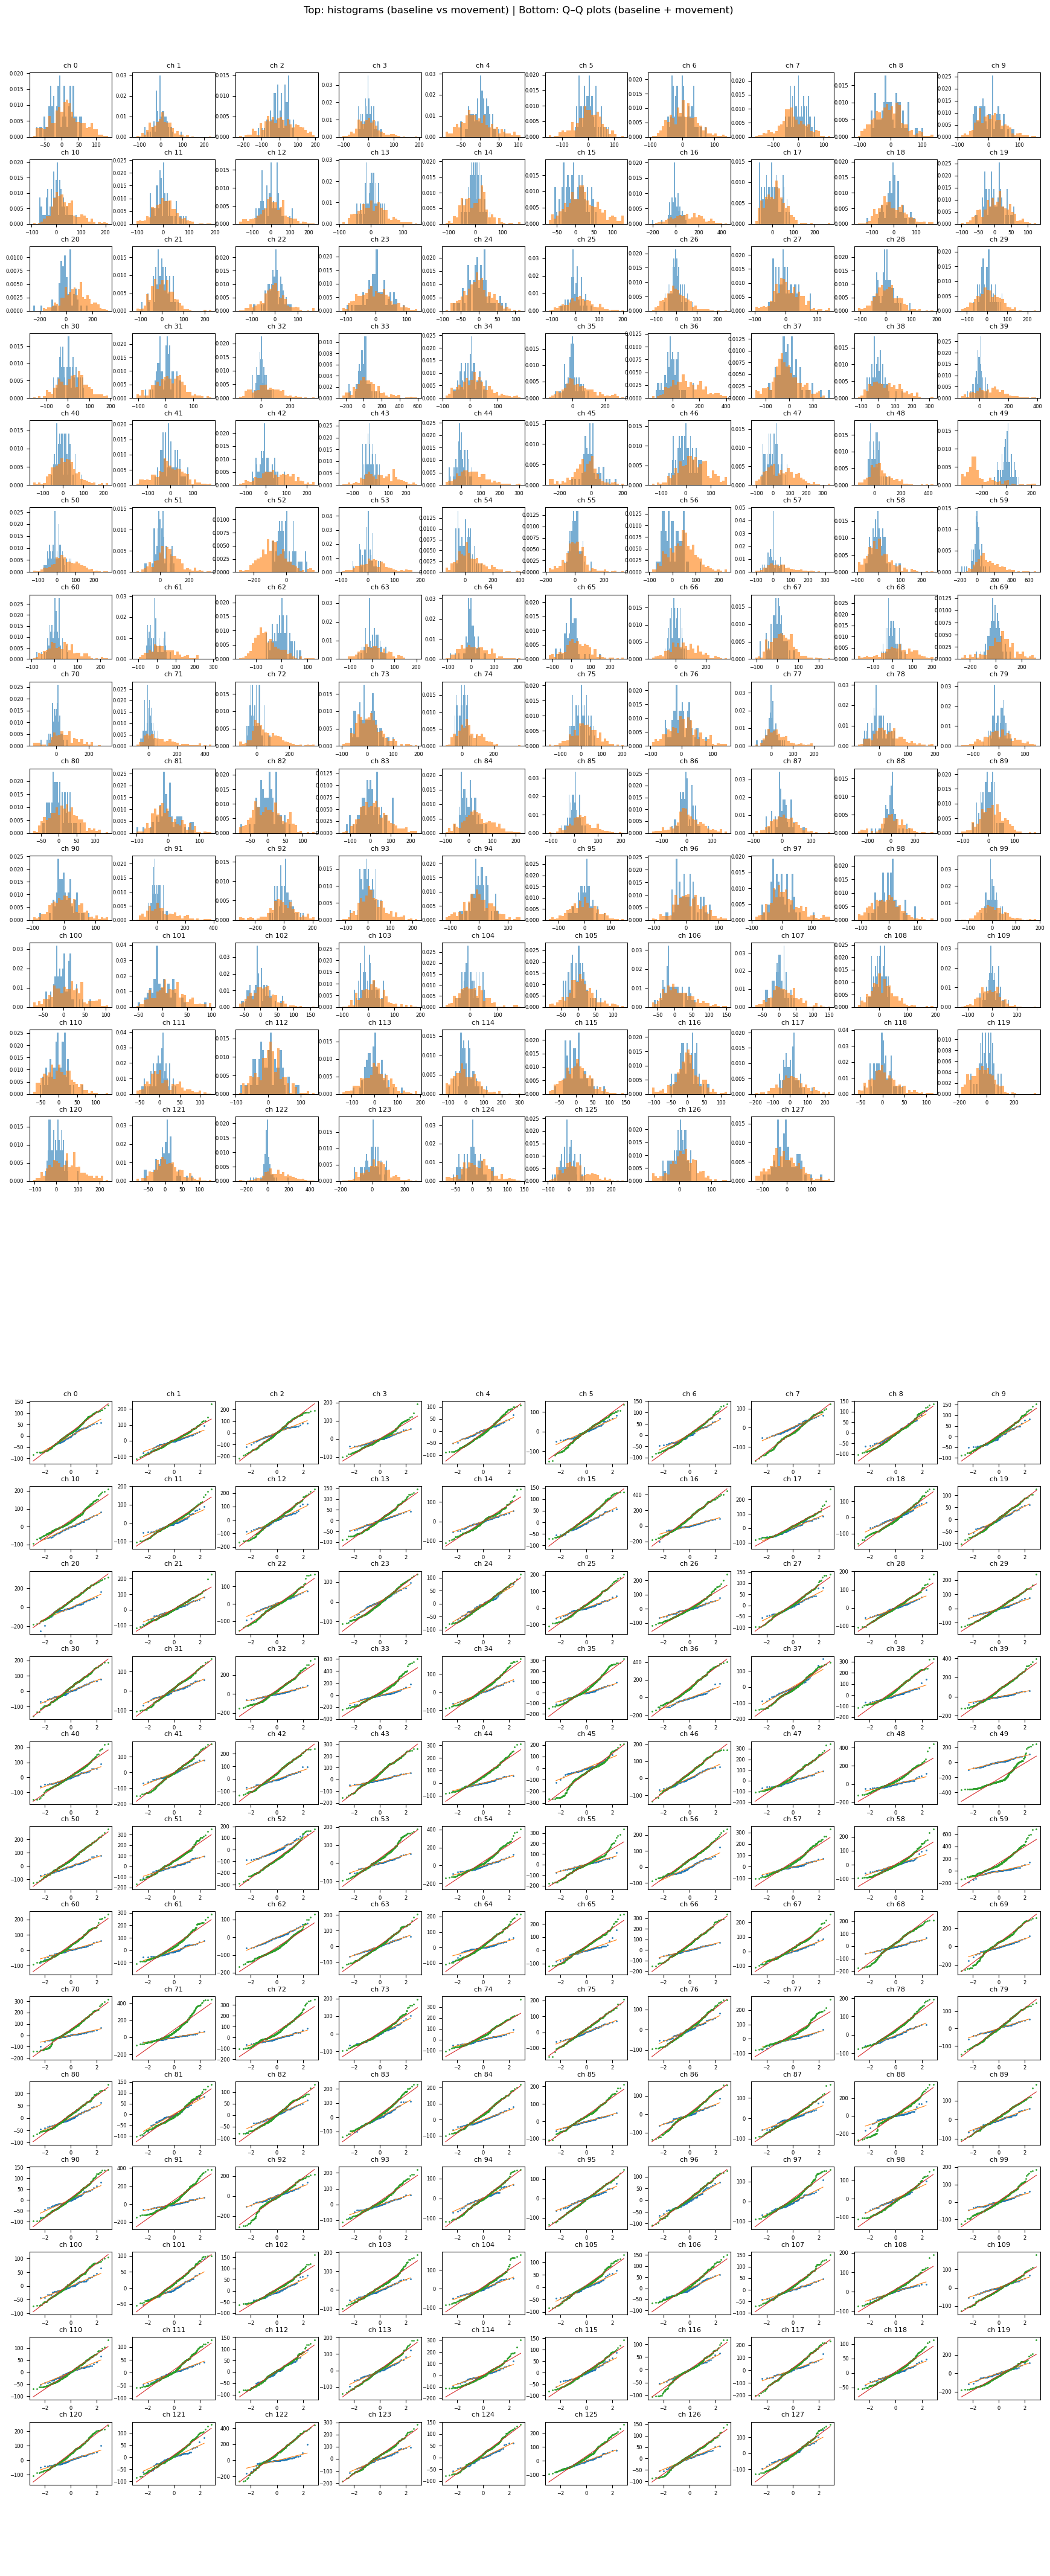

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

BASELINE_MS = (-600.0, -450.0)
MOVE_MS     = (-400.0,  400.0)

# Use the time axis that matches UA_rates_zeroed.shape[-1]
# Prefer UA_rel_t if available; otherwise derive centers from edges and crop.
if "UA_rel_t" in globals() and UA_rel_t is not None and len(UA_rel_t) == UA_rates_zeroed.shape[-1]:
    t_ms = np.asarray(UA_rel_t, float)
else:
    # fall back to edges -> centers, but FORCE length match to n_t
    n_t = UA_rates_zeroed.shape[-1]
    t_centers_ms = 0.5 * (UA_edges_ms[:-1] + UA_edges_ms[1:])
    t_ms = np.asarray(t_centers_ms[:n_t], float)  # crop if off-by-one (or more)

baseline_mask = (t_ms >= BASELINE_MS[0]) & (t_ms <= BASELINE_MS[1])
move_mask     = (t_ms >= MOVE_MS[0])     & (t_ms <= MOVE_MS[1])

n_trials, n_ch, n_t = UA_rates_zeroed.shape
nrows, ncols = 14, 10
bins = 30

fig = plt.figure(figsize=(18, 44))
gs_hist = fig.add_gridspec(nrows, ncols, left=0.05, right=0.98, top=0.97, bottom=0.52,
                           wspace=0.25, hspace=0.35)
gs_qq   = fig.add_gridspec(nrows, ncols, left=0.05, right=0.98, top=0.47, bottom=0.03,
                           wspace=0.25, hspace=0.35)

for ch in range(n_ch):
    r, c = divmod(ch, ncols)

    # NOTE: slice time on the last axis directly (clearer, avoids boolean mismatch bugs)
    baseline_vals = UA_rates_zeroed[:, ch, baseline_mask].ravel()
    move_vals     = UA_rates_zeroed[:, ch, move_mask].ravel()

    baseline_vals = baseline_vals[np.isfinite(baseline_vals)]
    move_vals     = move_vals[np.isfinite(move_vals)]

    axh = fig.add_subplot(gs_hist[r, c])
    axh.hist(baseline_vals, bins=bins, density=True, alpha=0.6, label="baseline")
    axh.hist(move_vals,     bins=bins, density=True, alpha=0.6, label="move")
    axh.set_title(f"ch {ch}", fontsize=8)
    axh.tick_params(labelsize=6)

    axq = fig.add_subplot(gs_qq[r, c])

    if baseline_vals.size >= 5:
        (osm_b, osr_b), (slope_b, intercept_b, _) = stats.probplot(baseline_vals, dist="norm")
        axq.plot(osm_b, osr_b, marker=".", linestyle="none", markersize=2)
        axq.plot(osm_b, slope_b * osm_b + intercept_b, linewidth=0.8)

    if move_vals.size >= 5:
        (osm_m, osr_m), (slope_m, intercept_m, _) = stats.probplot(move_vals, dist="norm")
        axq.plot(osm_m, osr_m, marker=".", linestyle="none", markersize=2)
        axq.plot(osm_m, slope_m * osm_m + intercept_m, linewidth=0.8)

    axq.set_title(f"ch {ch}", fontsize=8)
    axq.tick_params(labelsize=6)
    axq.set_xlabel("")
    axq.set_ylabel("")

# Turn off unused slots
for k in range(n_ch, nrows * ncols):
    r, c = divmod(k, ncols)
    fig.add_subplot(gs_hist[r, c]).axis("off")
    fig.add_subplot(gs_qq[r, c]).axis("off")

fig.suptitle("Top: histograms (baseline vs movement) | Bottom: Q–Q plots (baseline + movement)", y=0.995)
plt.show()


Top 128 channels by peak UA_med (global):

Region counts within selected top channels:
 [ 3] M1 superior: 35 channels
 [ 1] Dorsal premotor: 32 channels
 [ 2] M1 inferior: 31 channels
 [ 0] SMA: 30 channels


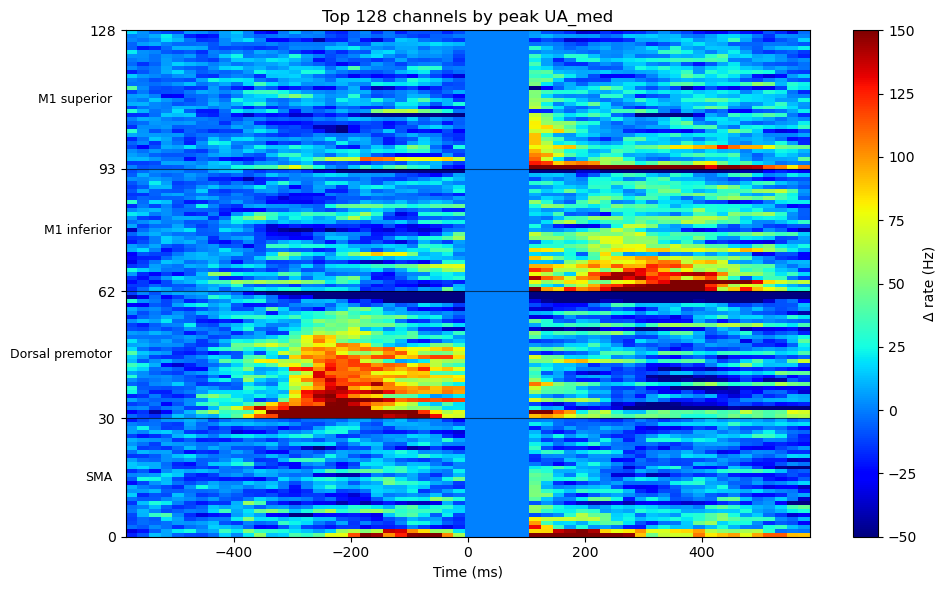

In [89]:
VMIN_UA, VMAX_UA = -50, 150
TOP_X = 128
WIN_MS = (-400.0, 400.0)

insert_at = 29  # column index where you want the blank gap

n_t = UA_med.shape[1]

# Prefer UA_rel_t if it matches UA_med's time axis
if "UA_rel_t" in globals() and UA_rel_t is not None and len(UA_rel_t) == n_t:
    t_ms = np.asarray(UA_rel_t, float)
else:
    # edges -> centers, then FORCE match to UA_med time bins
    t_centers_ms = 0.5 * (UA_edges_ms[:-1] + UA_edges_ms[1:])
    t_ms = np.asarray(t_centers_ms[:n_t], float)  # crop to 53

tmask = (t_ms >= WIN_MS[0]) & (t_ms <= WIN_MS[1])
if not np.any(tmask):
    raise ValueError(f"No UA time bins fall within {WIN_MS} ms (t_ms range {t_ms.min():.1f}..{t_ms.max():.1f})")

scores_all = np.nanmax(UA_med[:, tmask], axis=1)  # (n_ch,)
top_idx = np.argsort(scores_all)[::-1][:TOP_X]

UA_plot = UA_med[top_idx, :]
ua_ids_top = ua_ids_1based[top_idx]
ua_region_top = ua_region[top_idx]
scores_top = scores_all[top_idx]

# reorder by region then score (descending score within region)
order = np.lexsort((-scores_top, ua_region_top))  # region first, then score desc
UA_plot_ord = UA_plot[order, :]
ua_ids_ord = ua_ids_top[order]
ua_region_ord = ua_region_top[order]

# region boundaries
uniq_r, cnt_r = np.unique(ua_region_ord, return_counts=True)
bounds = np.cumsum(cnt_r)

# y-ticks at region centers
region_centers = bounds - cnt_r / 2
region_names = [str(x) for x in np.atleast_1d(ua_region_names)]
region_labels = [
    region_names[r] if 0 <= r < len(region_names) else f"region {r}"
    for r in uniq_r
]

n_ch_sel, n_t = UA_plot_ord.shape
UA_plot_gap = np.concatenate(
    [UA_plot_ord[:, :insert_at], np.zeros((n_ch_sel, 1)), UA_plot_ord[:, insert_at:]],
    axis=1
)
print(f"Top {TOP_X} channels by peak UA_med (global):")
print("\nRegion counts within selected top channels:")
for r, c in sorted(zip(uniq_r, cnt_r), key=lambda x: -x[1]):
    name = region_names[r] if 0 <= r < len(region_names) else "<missing name>"
    print(f" [{r:2d}] {name}: {c} channels")

y_edges = np.arange(TOP_X + 1)

plt.figure(figsize=(10, 6))
plt.pcolormesh(
    UA_edges_ms,       # OK for x edges
    y_edges,
    UA_plot_gap,
    cmap=cmap_local_ua,
    vmin=VMIN_UA,
    vmax=VMAX_UA,
    shading="auto",
    antialiased=False,
    rasterized=True,
)

for b in bounds[:-1]:
    plt.axhline(b, color="k", lw=0.8, alpha=0.6)

boundary_ticks = np.r_[0, bounds]
plt.yticks(boundary_ticks)

ax = plt.gca()
for yc, lab in zip(region_centers, region_labels):
    ax.text(
        -0.02, yc, lab,
        transform=ax.get_yaxis_transform(),
        va="center", ha="right", fontsize=9,
    )

plt.xlabel("Time (ms)")
plt.title(f"Top {TOP_X} channels by peak UA_med")
plt.colorbar(label="Δ rate (Hz)")
plt.tight_layout()
plt.show()


In [86]:
UA_rel_t[28]

np.float64(-15.0)

In [9]:
cond_label_extras = {
    "Baseline": "Control reaches",
    5: "400Hz (1-32)",
    6: "400Hz (1-32)",
    7: "400Hz (33-64)",
    9: "32 ch (Rest, 33-64)",
    10: "130Hz (1-32)",
    11: "130Hz (33-64)",
    12: "1-8",
    13: "5-12",
    14: "9-16",
    15: "13-20",
    16: "17-24",
    17: "21-28",
    18: "25-32",
    19: "29-36",
    20: "33-40",
    21: "37-44",
    23: "400Hz (1-32) Late",
    24: "400Hz (32-64) Late",
    25: "130Hz (1-32) Late",
    27: "130Hz (1-32) Late",
}

[rsa][control] running 'NPRW', window=105.0–400.0 ms
[rsa][control] keeping conds = ['Baseline']
[rsa][control][skip] wrong_port=2 | not_control=42 | too_few_trials=0 | empty=2
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/control_only/RSA_control_only_NPRW_neural_Targets_AB_win105-400.svg


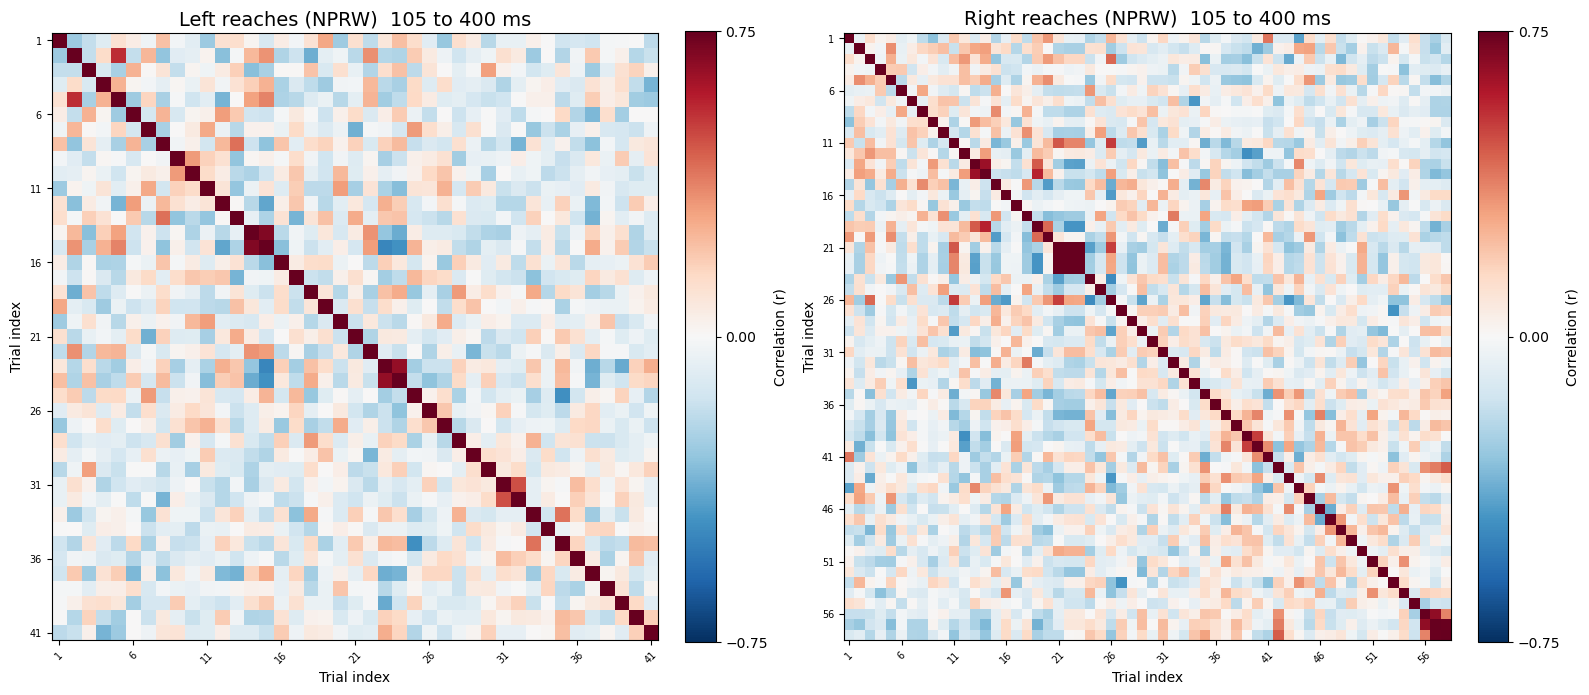

[rsa][control] done.


In [10]:
%matplotlib inline

run_trial_rsa_control_only_from_peristim(
    source="NPRW",
    corr_win_ms=(105.0, 400.0),
    keep_baseline_port="A",
    control_conds=("Baseline",),
    vmin=-0.75, vmax=0.75,
    out_subdir="control_only",
    show=True,
)

# run_trial_rsa_control_only_from_peristim(
#     source="UA",
#     corr_win_ms=(105.0, 400.0),
#     cond_label_extras=cond_label_extras,
#     vmin=-0.75, vmax=0.75,
#     keep_baseline_port="A",
#     control_conds=("Baseline",),
#     tick_every=5,
# )

[rsa] running RSA for 'NPRW', window=-300.0–-5.0 ms
[rsa][skip-summary] skip_conds=3,8,9,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote mat /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/RSA_MAT_M1i/RSA_mat_NPRW_Target_A_-300--5.mat
[rsa] wrote mat /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/RSA_MAT_M1i/RSA_mat_NPRW_Target_B_-300--5.mat
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_NPRW_neural_Targets_AB_win-300--5.svg


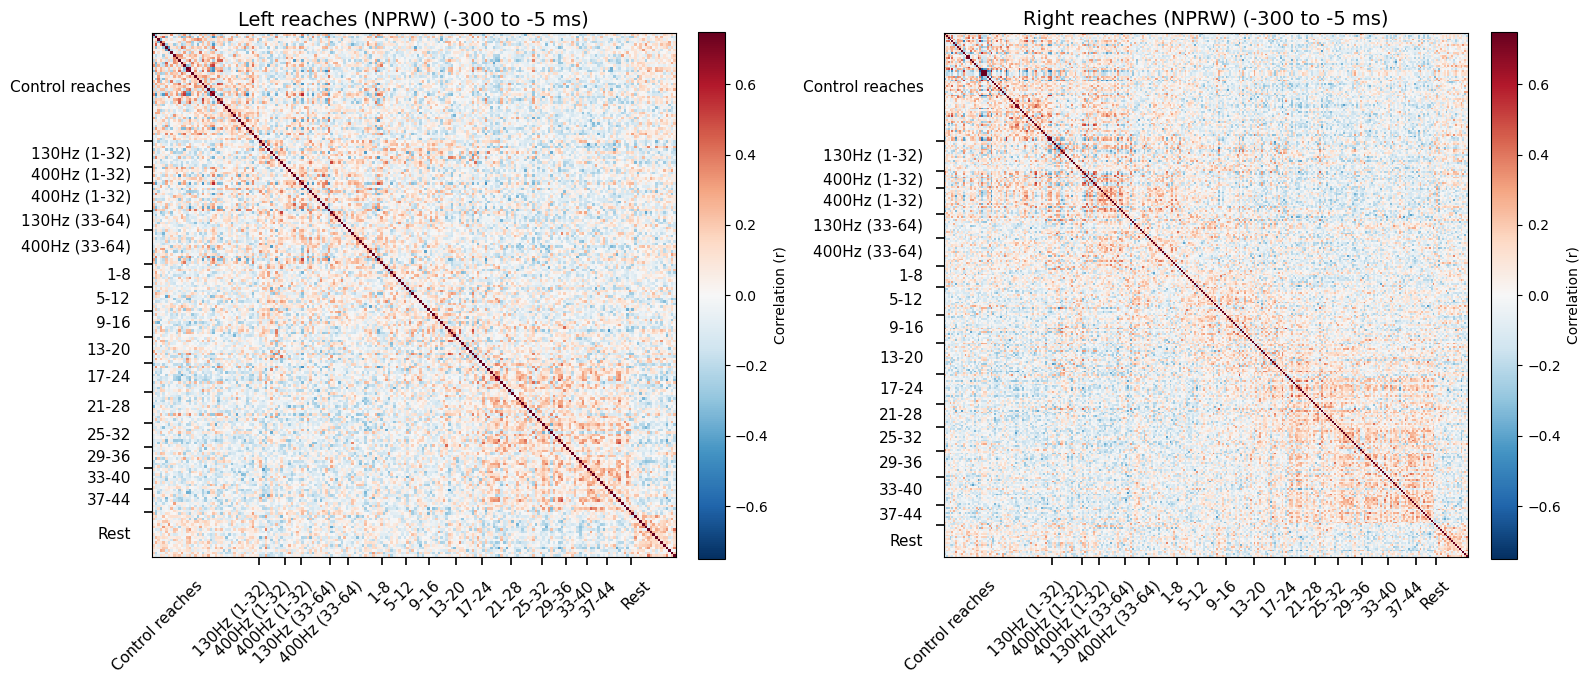

[rsa] final: total trials (pre-extra)=447  features=118
[rsa] running RSA for 'UA', window=-300.0–-5.0 ms
[rsa][skip-summary] skip_conds=3,8,9,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote mat /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/RSA_MAT_M1i/RSA_mat_UA_Target_A_-300--5.mat
[rsa] wrote mat /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/RSA_MAT_M1i/RSA_mat_UA_Target_B_-300--5.mat
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_UA_neural_Targets_AB_win-300--5.svg


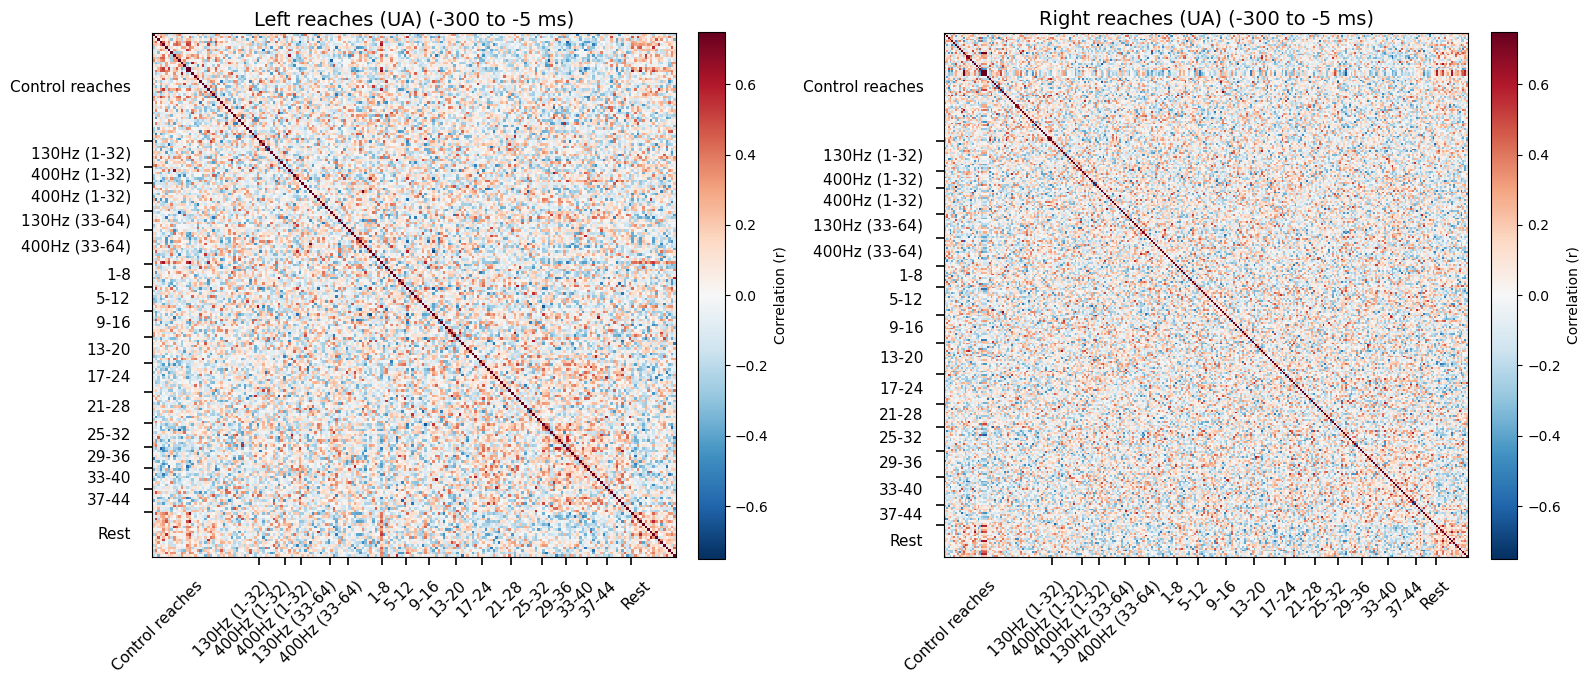

[rsa] final: total trials (pre-extra)=447  features=31


In [11]:
run_trial_rsa_from_peristim(source="NPRW", 
                            corr_win_ms=(-300.0, -5.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 8, 9, 23, 24, 25, 27},
                            cond_order=["Baseline", 10, 5, 6, 11, 7],
                            channels=slice(0, 118),
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )
#M1 only
run_trial_rsa_from_peristim(source="UA", 
                            corr_win_ms=(-300.0, -5.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 8, 9, 23, 24, 25, 27},
                            cond_order=["Baseline", 10, 5, 6, 11, 7],
                            channels=slice(62, 93),
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )

[rsa] running RSA for 'NPRW', window=105.0–400.0 ms
[rsa][skip-summary] skip_conds=3,8,9,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_NPRW_neural_Targets_AB_win105-400.svg


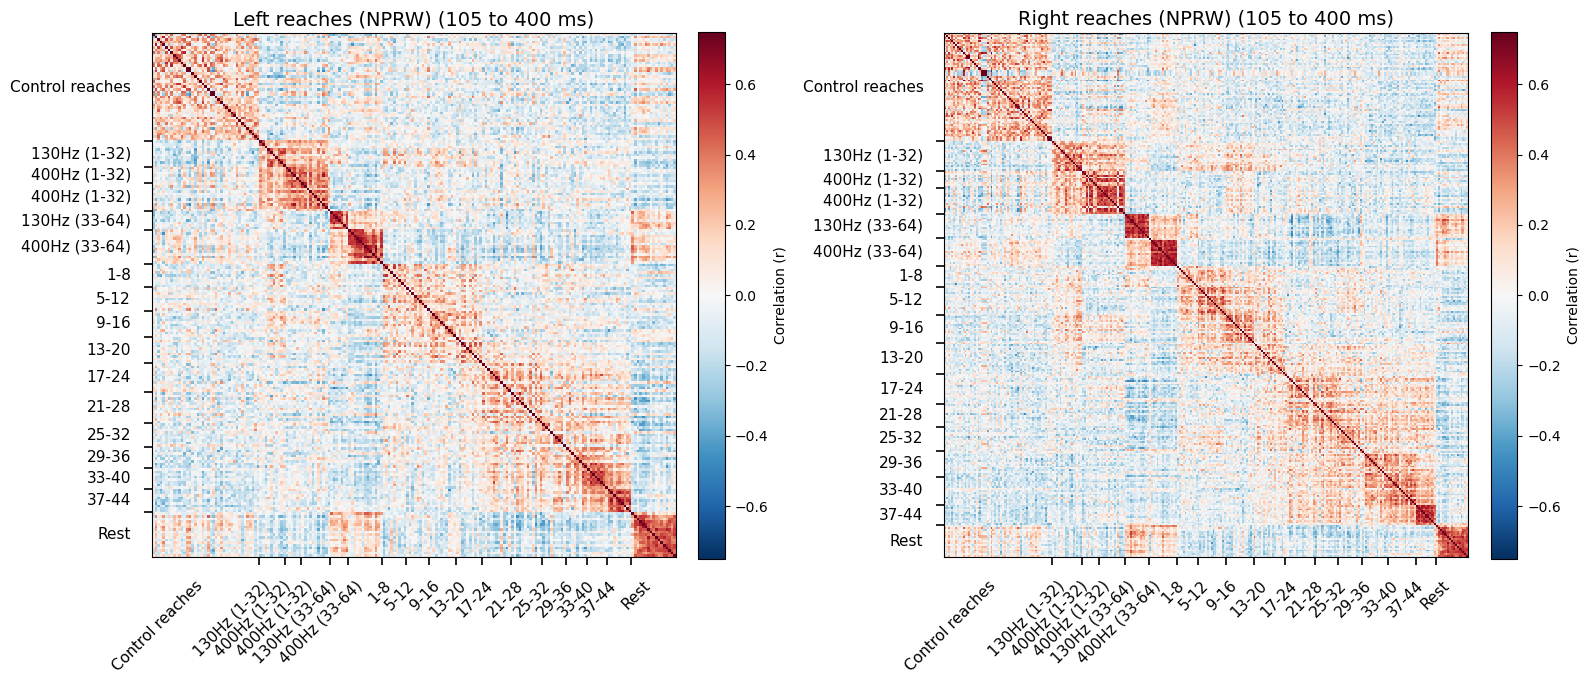

[rsa] final: total trials (pre-extra)=447  features=118


In [ ]:
run_trial_rsa_from_peristim(source="NPRW", 
                            corr_win_ms=(105.0, 400.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 8, 9, 23, 24, 25, 27},
                            cond_order=["Baseline", 10, 5, 6, 11, 7],
                            channels=slice(0, 118),
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )

[rsa] running RSA for 'NPRW', window=105.0–400.0 ms
[rsa][skip-summary] skip_conds=3,8,9,12,13,14,15,16,17,18,19,20,21,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_NPRW_neural_Targets_AB_win105-400.svg


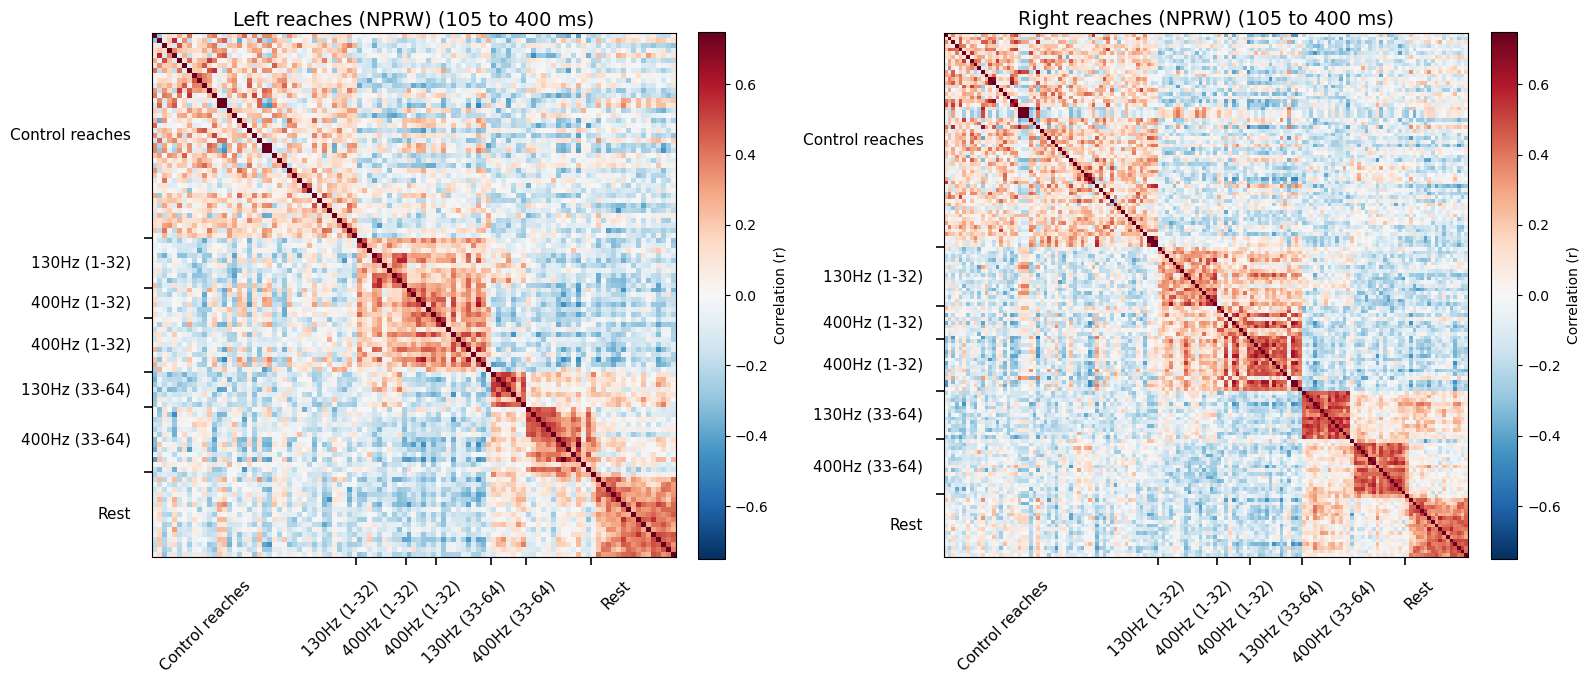

[rsa] final: total trials (pre-extra)=213  features=118


In [ ]:
# cond_label_extras = {
#     "Baseline": "Control reaches",
#     5: "400Hz (1-32)",
#     6: "400Hz (1-32)",
#     7: "400Hz (33-64)",
#     9: "32 ch (Rest, 33-64)",
#     10: "130Hz (1-32)",
#     11: "130Hz (33-64)",
#     12: "1-8",
#     13: "5-12",
#     14: "9-16",
#     15: "13-20",
#     16: "17-24",
#     17: "21-28",
#     18: "25-32",
#     19: "29-36",
#     20: "33-40",
#     21: "37-44",
#     23: "32 ch (1-32) Late",
#     24: "32 ch (32-64) Late",
#     25: "130Hz (1-32) Late",
#     27: "130Hz (1-32) Late",
# }
# 
run_trial_rsa_from_peristim(source="NPRW", 
                            corr_win_ms=(105.0, 400.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 27},
                            cond_order=["Baseline", 10, 5, 6, 11, 7],
                            channels=slice(0, 118),
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )

[rsa] running RSA for 'NPRW', window=105.0–400.0 ms
[rsa][skip-summary] skip_conds=3,5,6,7,8,9,10,11,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_NPRW_neural_Targets_AB_win105-400.svg


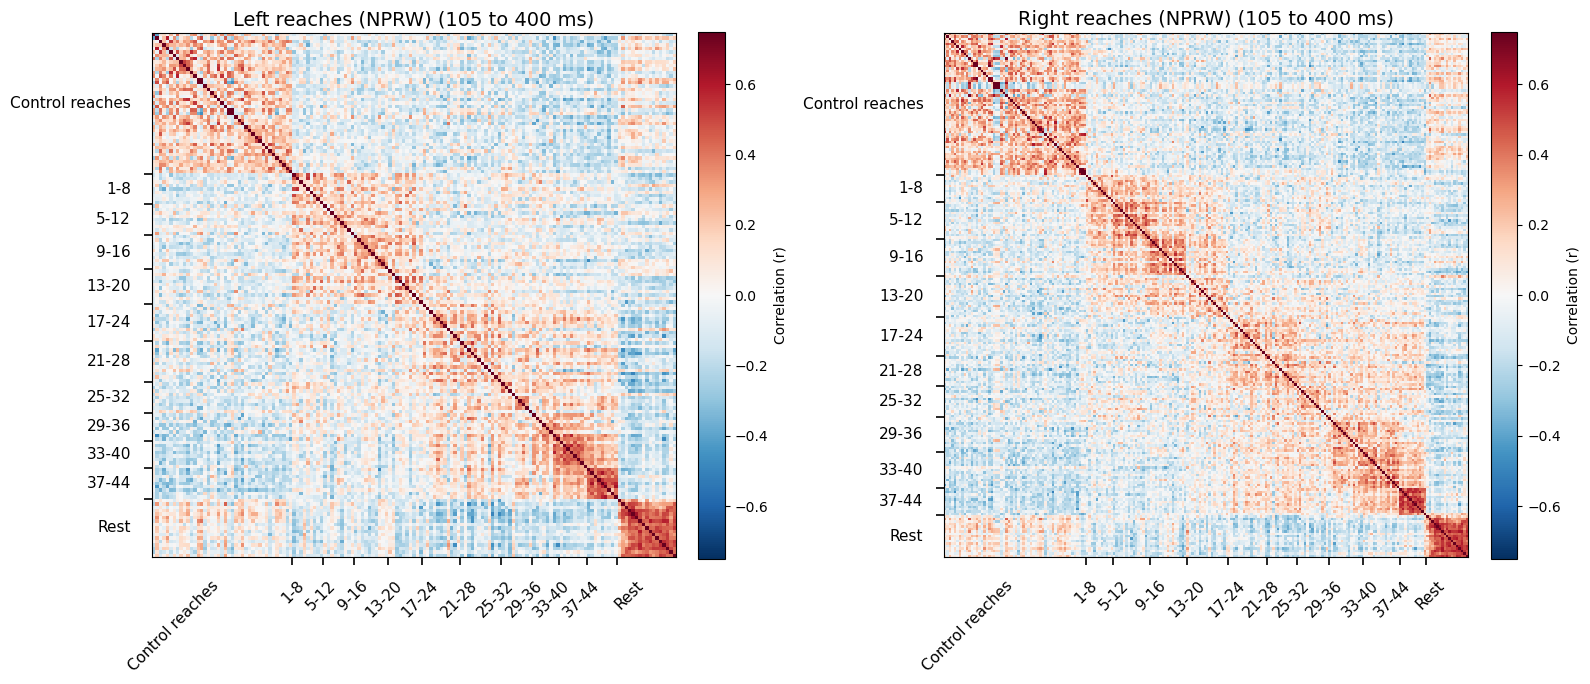

[rsa] final: total trials (pre-extra)=333  features=118


In [57]:
run_trial_rsa_from_peristim(source="NPRW", 
                            corr_win_ms=(105.0, 400.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 5, 6, 7, 8, 9, 10, 11, 23, 24, 25, 27},
                            cond_order=["Baseline"],
                            channels=slice(0, 118),
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )



[rsa] running RSA for 'NPRW', window=105.0–400.0 ms
[rsa][skip-summary] skip_conds=3,8,9,12,13,14,15,16,17,18,19,20,21 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_NPRW_neural_Targets_AB_win105-400.svg


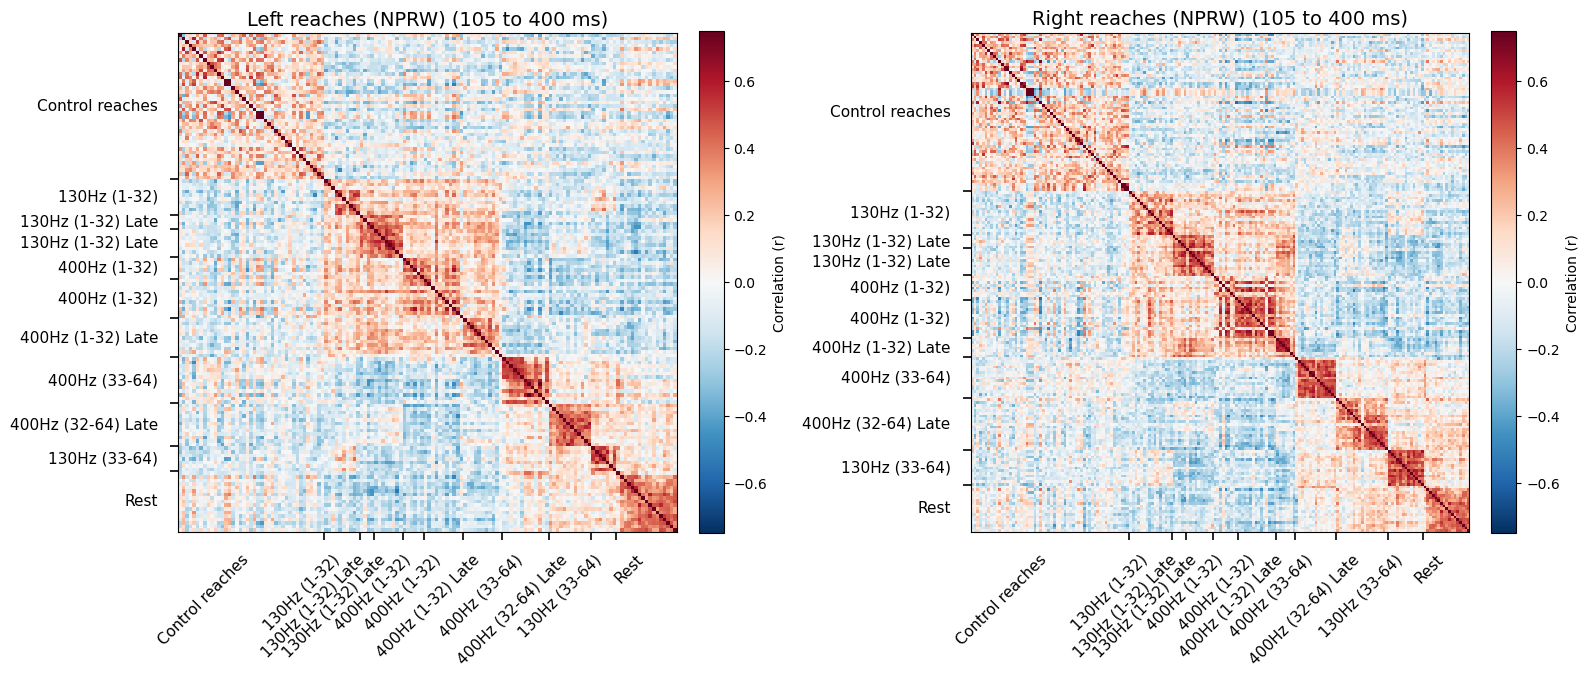

[rsa] final: total trials (pre-extra)=289  features=118


In [60]:
run_trial_rsa_from_peristim(source="NPRW", 
                            corr_win_ms=(105.0, 400.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21},
                            cond_order=["Baseline", 10, 25, 27, 5, 6, 23, 7, 24],
                            channels=slice(0, 118),
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )

[rsa] running RSA for 'NPRW', window=105.0–400.0 ms
[rsa][skip-summary] skip_conds=3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_NPRW_neural_Targets_AB_win105-400.svg


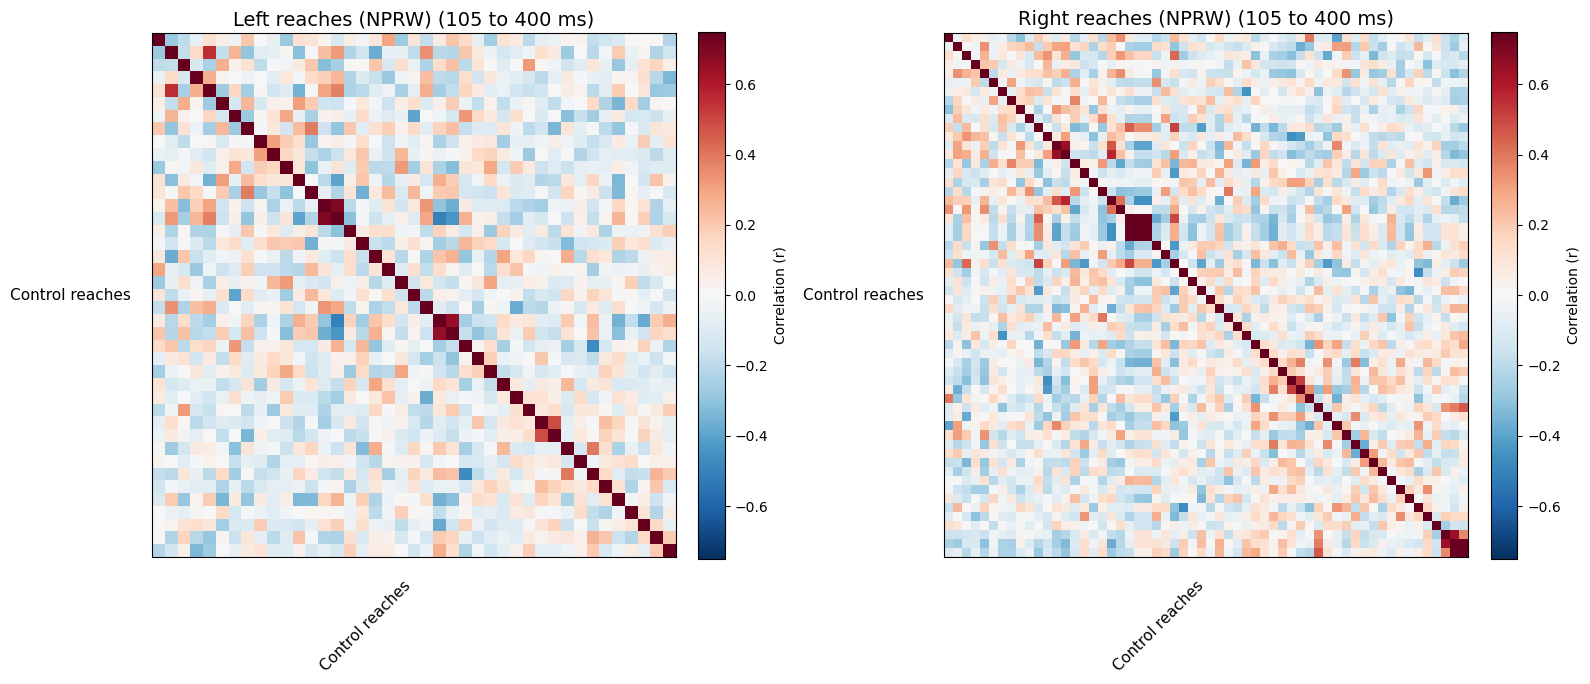

[rsa] final: total trials (pre-extra)=99  features=118


In [67]:
run_trial_rsa_from_peristim(source="NPRW", 
                            corr_win_ms=(105.0, 400.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 27},
                            cond_order=["Baseline"],
                            channels=slice(0, 118),
                            # extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            # extra_block_label="Rest",
                            show=True,
                            )



In [ ]:
#M1 only
run_trial_rsa_from_peristim(source="UA", 
                            corr_win_ms=(105.0, 400.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 8, 9, 23, 24, 25, 27},
                            cond_order=["Baseline", 10, 5, 6, 11, 7],
                            channels=slice(62, 93),
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )


[rsa] running RSA for 'UA', window=105.0–400.0 ms
[rsa][skip-summary] skip_conds=3,8,9,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17


[rsa] running RSA for 'UA', window=-300.0–-5.0 ms
[rsa][skip-summary] skip_conds=3,8,9,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_UA_neural_Targets_AB_win-300--5.svg


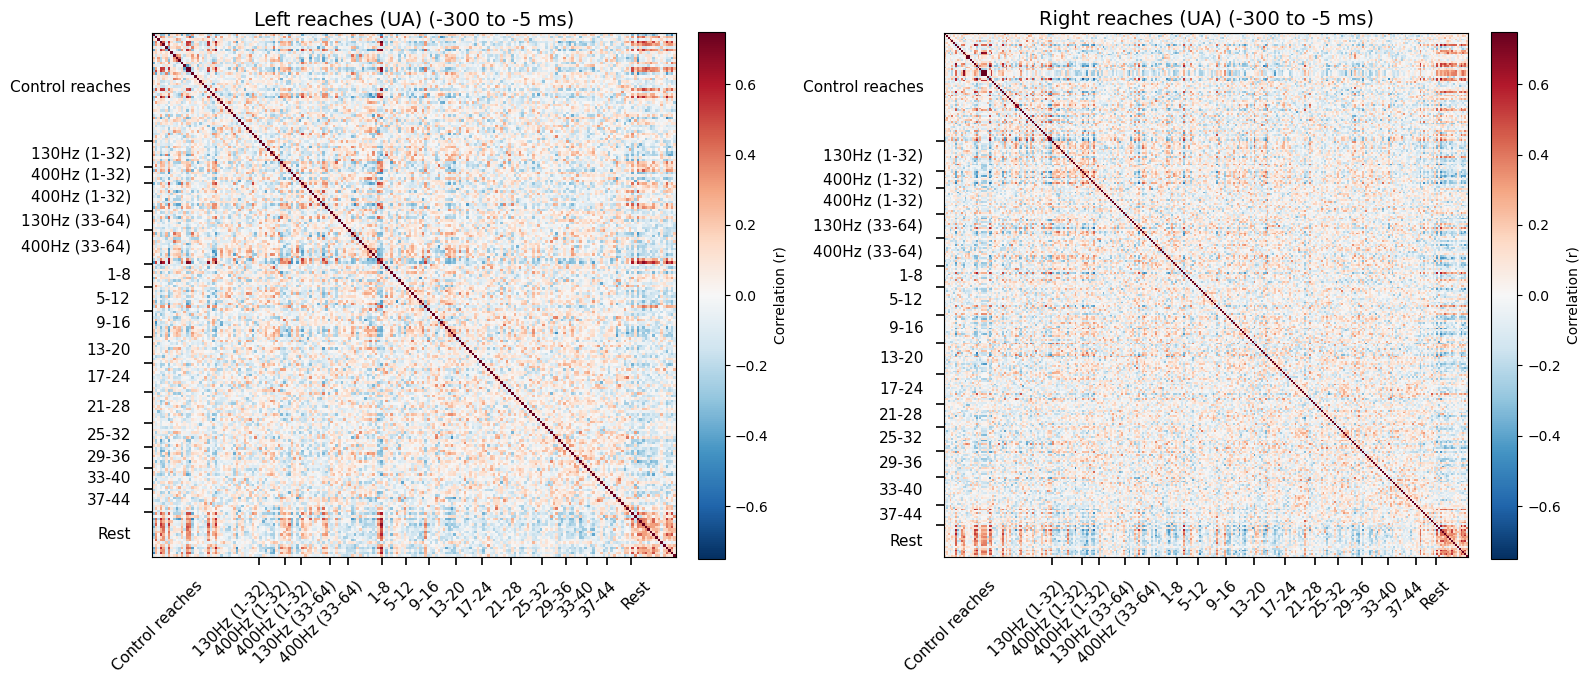

[rsa] final: total trials (pre-extra)=447  features=128


In [68]:
run_trial_rsa_from_peristim(source="UA", 
                            corr_win_ms=(-300.0, -5.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 8, 9, 23, 24, 25, 27},
                            cond_order=["Baseline", 10, 5, 6, 11, 7],
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )

[rsa] running RSA for 'UA', window=-300.0–-5.0 ms
[rsa][skip-summary] skip_conds=3,8,9,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_UA_neural_Targets_AB_win-300--5.svg


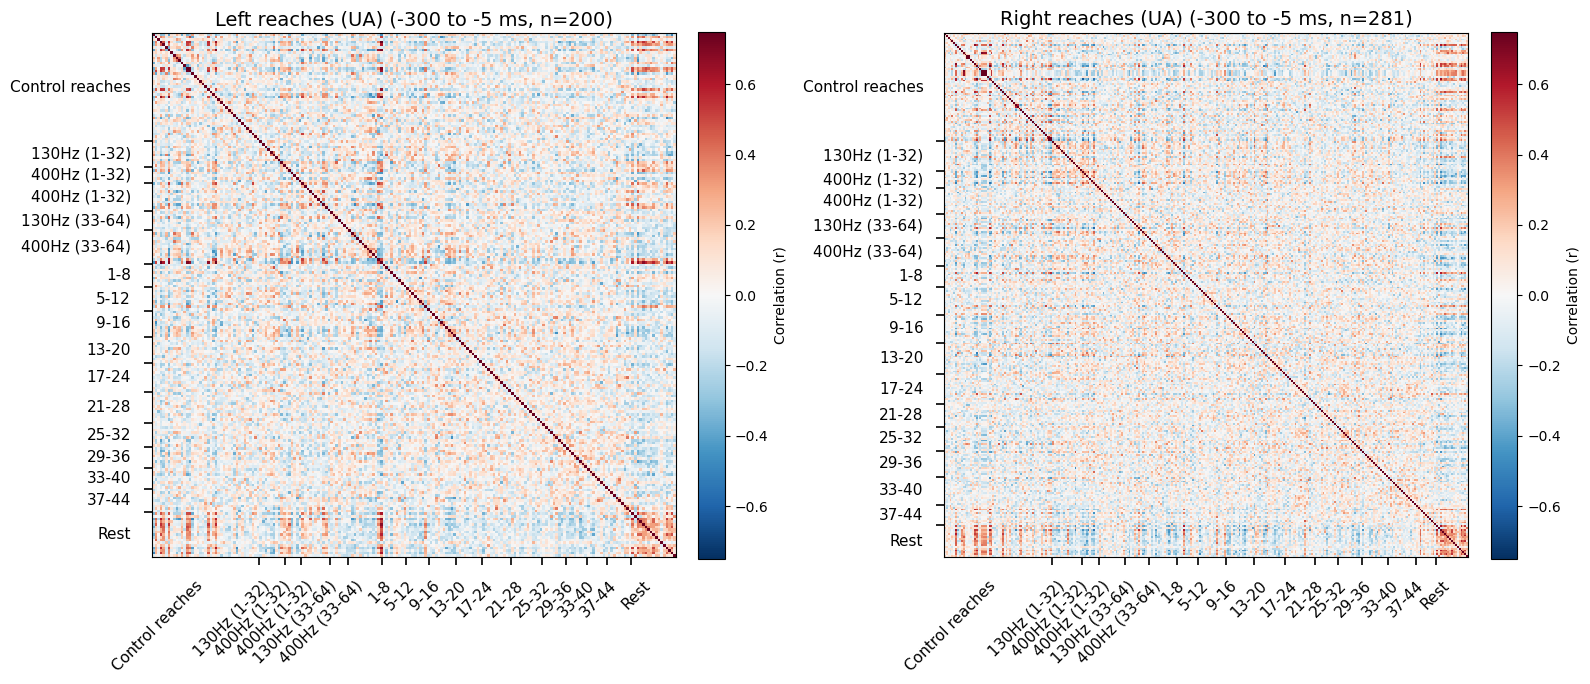

[rsa] final: total trials (pre-extra)=447  features=128
[rsa] running RSA for 'UA', window=105.0–400.0 ms
[rsa][skip-summary] skip_conds=3,8,9,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_UA_neural_Targets_AB_win105-400.svg


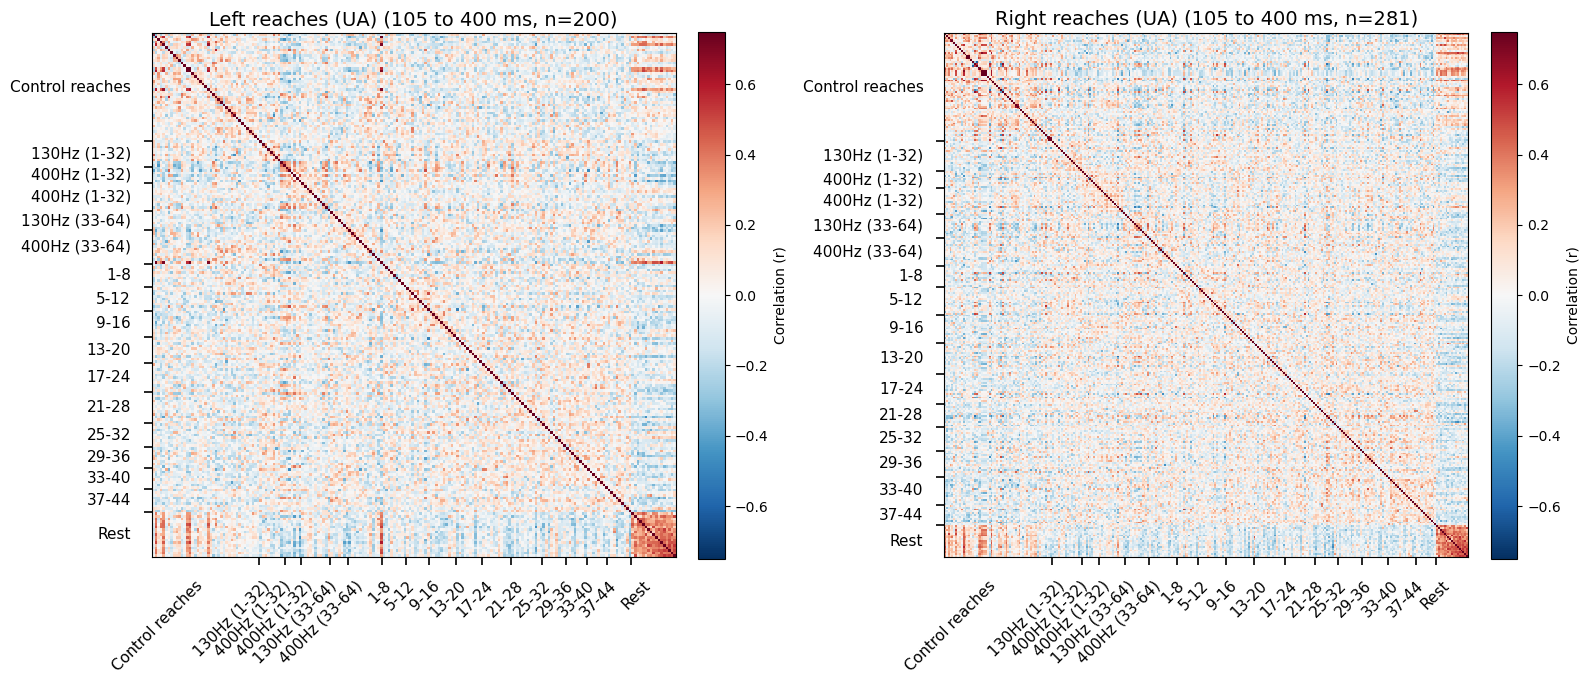

[rsa] final: total trials (pre-extra)=447  features=128
[rsa] running RSA for 'UA', window=105.0–400.0 ms
[rsa][skip-summary] skip_conds=3,8,9,12,13,14,15,16,17,18,19,20,21,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_UA_neural_Targets_AB_win105-400.svg


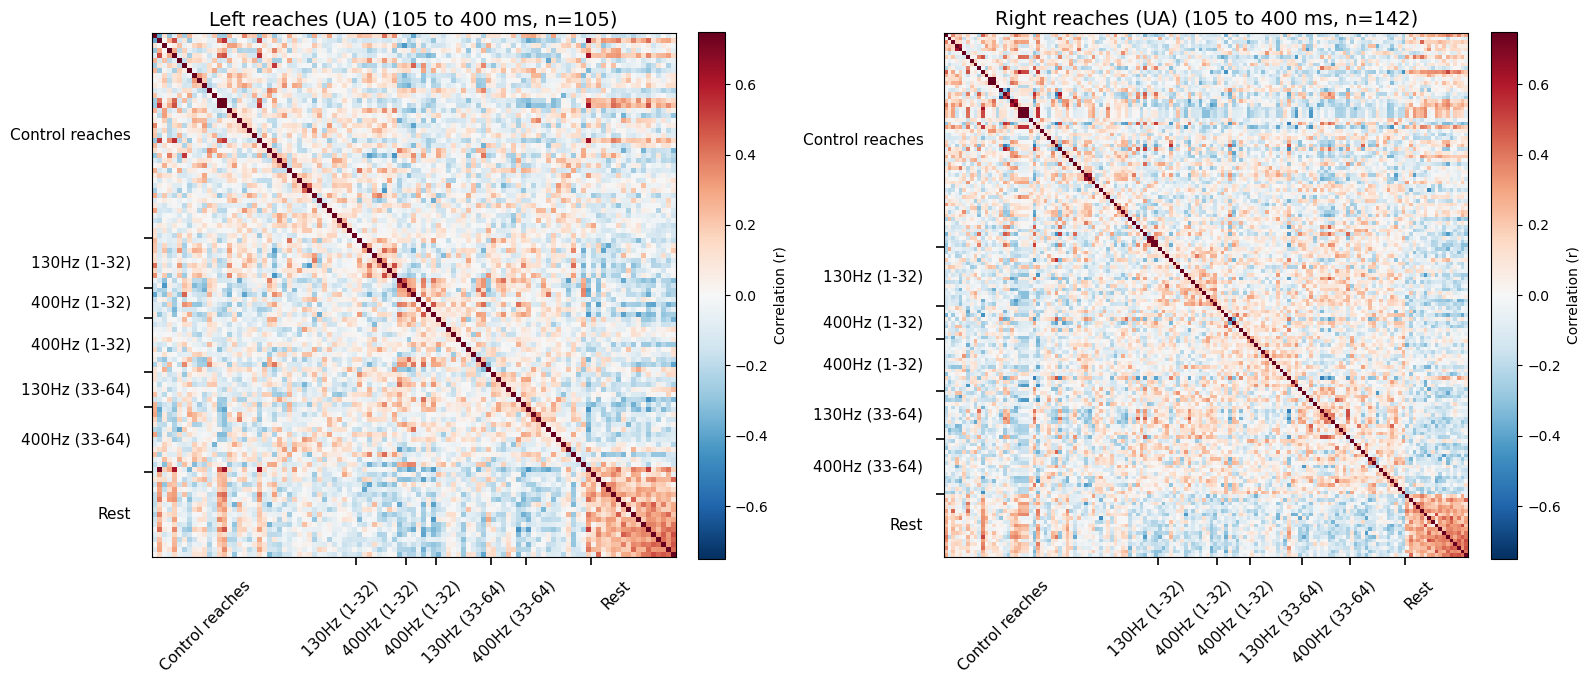

[rsa] final: total trials (pre-extra)=213  features=128
[rsa] running RSA for 'UA', window=105.0–400.0 ms
[rsa][skip-summary] skip_conds=3,5,6,7,8,9,10,11,23,24,25,27 | baseline_wrong_port(!=A)=2 | empty_or_missing=2
[rsa] extra block loaded: peristim__NRR_RW011_251203_143401__BR_009_target_A.npz  n_trials=17
[rsa] wrote combined figure /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/rsa_from_peristim/RSA_from_peristim_UA_neural_Targets_AB_win105-400.svg


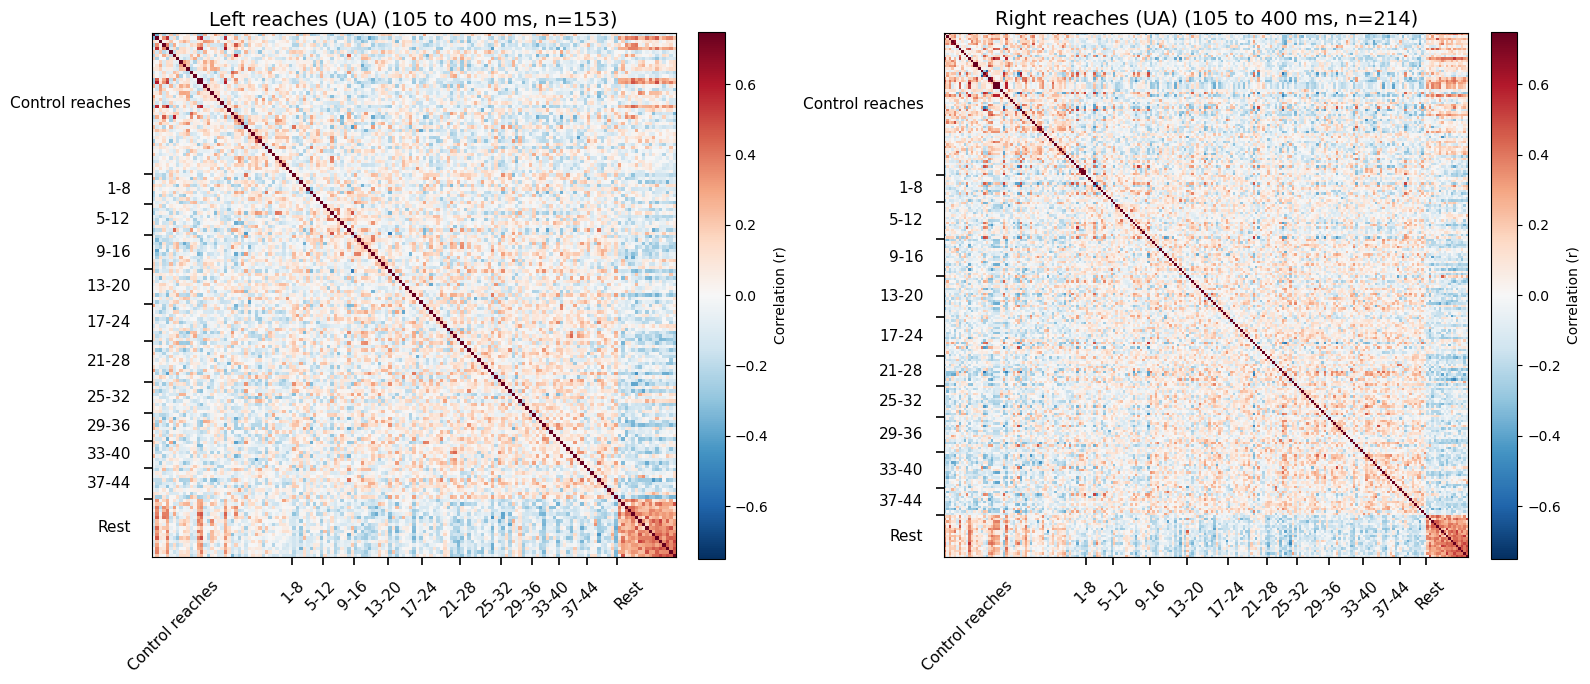

[rsa] final: total trials (pre-extra)=333  features=128


In [ ]:












run_trial_rsa_from_peristim(source="UA", 
                            corr_win_ms=(105.0, 400.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 8, 9, 23, 24, 25, 27},
                            cond_order=["Baseline", 10, 5, 6, 11, 7],
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )

run_trial_rsa_from_peristim(source="UA", 
                            corr_win_ms=(105.0, 400.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 27},
                            cond_order=["Baseline", 10, 5, 6, 11, 7],
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )


run_trial_rsa_from_peristim(source="UA", 
                            corr_win_ms=(105.0, 400.0),
                            cond_label_extras=cond_label_extras,
                            vmin=-0.75, vmax=0.75,
                            keep_baseline_port='A',
                            skip_conds = {2, 3, 5, 6, 7, 8, 9, 10, 11, 23, 24, 25, 27},
                            cond_order=["Baseline"],
                            extra_block_npz=Path("/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_143401__BR_009_target_A.npz").expanduser(),
                            extra_block_label="Rest",
                            show=True,
                            )

In [48]:
cond_label_extras = {
    "Baseline": "Control reaches",
    5: "32 ch (1-32)",
    6: "32 ch (1-32)",
    7: "32 ch (33-64)",
    9: "32 ch (Rest, 33-64)",
    10: "130Hz (1-32)",
    11: "130Hz (33-64)",
    23: "32 ch (1-32) Late",
    24: "32 ch (32-64) Late",
    25: "130Hz (1-32) Late",
    27: "130Hz (1-32) Late",
}

In [75]:
scores_all = np.nanmax(UA_med[:, tmask], axis=1)  # (n_ch,)
top_idx = np.argsort(scores_all)[::-1][:TOP_X]

UA_plot = UA_med[top_idx, :]
ua_ids_top = ua_ids_1based[top_idx]
ua_region_top = ua_region[top_idx]
scores_top = scores_all[top_idx]
# --- reorder top channels by region (then by score) ---
order = np.lexsort((scores_top, ua_region_top))  # region first, then score
UA_plot_ord = UA_plot[order, :]
ua_ids_ord = ua_ids_top[order]
ua_region_ord = ua_region_top[order]



# region boundaries
uniq_r, cnt_r = np.unique(ua_region_ord, return_counts=True)
bounds = np.cumsum(cnt_r)

# y-ticks at region centers
region_centers = bounds - cnt_r / 2
region_names = [str(x) for x in np.atleast_1d(ua_region_names)]
region_labels = [
    region_names[r] if 0 <= r < len(region_names) else f"region {r}"
    for r in uniq_r
]

print(f"Top {TOP_X} channels by peak UA_med (global):")
# print(" channel IDs (1-based):", ua_ids_top)
# # print(" peak scores:", scores_top)
print("\nRegion counts within selected top channels:")
for r, c in sorted(zip(uniq_r, cnt_r), key=lambda x: -x[1]):
    name = region_names[r] if 0 <= r < len(region_names) else "<missing name>"
    print(f" [{r:2d}] {name}: {c} channels")

y_edges = np.arange(TOP_X + 1)

plt.figure(figsize=(10, 6))
plt.pcolormesh(
    UA_edges_ms,
    y_edges,
    UA_plot_ord,
    cmap=cmap_local_ua,
    vmin=VMIN_UA,
    vmax=VMAX_UA,
    shading="auto",
    antialiased=False,
    rasterized=True,
)

# --- draw boundary lines ---
for b in bounds[:-1]:
    plt.axhline(b, color="k", lw=0.8, alpha=0.6)

# --- ticks ONLY at boundaries (between regions) ---
boundary_ticks = np.r_[0, bounds]  # include 0 and the final end
plt.yticks(boundary_ticks)

# Optional: add region names as text at block centers
region_names = [str(x) for x in np.atleast_1d(ua_region_names)]
region_labels = [
    region_names[r] if 0 <= r < len(region_names) else f"region {r}"
    for r in uniq_r
]
ax = plt.gca()

# place region labels just left of the y-axis
for yc, lab in zip(region_centers, region_labels):
    ax.text(
        -0.02, yc, lab,                 # x < 0 puts text left of axis
        transform=ax.get_yaxis_transform(),
        va="center",
        ha="right",
        fontsize=9,
    )


plt.xlabel("Time (ms)")
# plt.ylabel("Region boundaries")
plt.title(f"Top {TOP_X} channels by peak UA_med")
plt.colorbar(label="Δ rate (Hz)")
plt.tight_layout()
plt.show()

NameError: name 'UA_med' is not defined

In [ ]:
def run_per_channel_rsa_from_peristim(
    source: str,
    corr_win_ms: tuple[float, float],
    cond_label_extras: dict,
    skip_conds=None,
    channels=None,
    keep_baseline_port="A",
    vmin: float = -0.75,
    vmax: float = 0.75,
):
    out_subdir = "per_channel"
    assert source not in (None, ""), "run_per_channel_rsa_from_peristim: 'source' is required."
    assert corr_win_ms is not None and len(corr_win_ms) == 2, "run_per_channel_rsa_from_peristim: 'corr_win_ms' must be (w0, w1)."

    if channels is None:
        channels = range(0, 118)

    for ch in channels:
        ch = int(ch)
        print(f"[rsa][per-channel] ch={ch:03d}")
        out_subdir_base = "per_channel"

        run_trial_rsa_from_peristim(
            source=source,
            corr_win_ms=corr_win_ms,
            cond_label_extras=cond_label_extras,
            skip_conds=skip_conds,
            keep_baseline_port=keep_baseline_port,
            channels=[ch],
            vmin=vmin,
            vmax=vmax,
            show=False,                 # <- no display
            out_subdir=f"{out_subdir_base}/ch{ch:03d}",
            time_as_features=True,
        )


In [74]:
cond_label_extras = {
    "Baseline": "Control reaches",
    5: "400Hz (1-32)",
    6: "400Hz (1-32)",
    7: "400Hz (33-64)",
    9: "32 ch (Rest, 33-64)",
    10: "130Hz (1-32)",
    11: "130Hz (33-64)",
    12: "1-8",
    13: "5-12",
    14: "9-16",
    15: "13-20",
    16: "17-24",
    17: "21-28",
    18: "25-32",
    19: "29-36",
    20: "33-40",
    21: "37-44",
    23: "400Hz (1-32) Late",
    24: "400Hz (32-64) Late",
    25: "130Hz (1-32) Late",
    27: "130Hz (1-32) Late",
}

run_per_channel_rsa_from_peristim(
    source="UA",
    corr_win_ms=(105.0, 400.0),
    cond_label_extras=cond_label_extras,
    skip_conds={2, 3, 8, 9, 23, 24, 25, 27},
    channels=range(0, 118),
    keep_baseline_port="A",
)

# run_per_channel_rsa_from_peristim(
#     source="UA",                 # or "NPRW"
#     corr_win_ms=(105.0, 400.0),
#     skip_conds = {2, 3, 8, 9, 23, 24, 25, 27},
#     channels=range(0, 118),        # adjust as needed
#     keep_baseline_port="A",
#     show,                 # NEW: never show in Jupyter
#     out_subdir: str | None = None,      # NEW: e.g. "per_channel"
# )




NameError: name 'run_per_channel_rsa_from_peristim' is not defined